Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range (95%): 7.739 to 8.911
  Global Δlog(Σ_SFR) axis limits: ±1.175
  Global Δ[O/H] axis limits: ±0.262
  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):
    Bin 01 (7.84): n=450, r=N/A (no trend or too few in 3σ)
    Bin 02 (8.03): n=2240, r=0.433 (p=5.28e-102)
    Bin 03 (8.23): n=5467, r=0.311 (p=3.25e-121)
    Bin 04 (8.42): n=3864, r=0.268 (p=5.05e-63)
    Bin 05 (8.62): n=1435, r=0.238 (p=9.89e-20)
    Bin 06 (8.81): n=705, r=0.097 (p=0.0101)

Processing NGC4064 ...
  Σ* range (95%): 7.180 to 9.130
  Global Δlog(Σ_SFR) axis limits: ±2.070
  Global Δ[O/H] axis limits: ±0.26

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_36001/1746847697.py:453: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


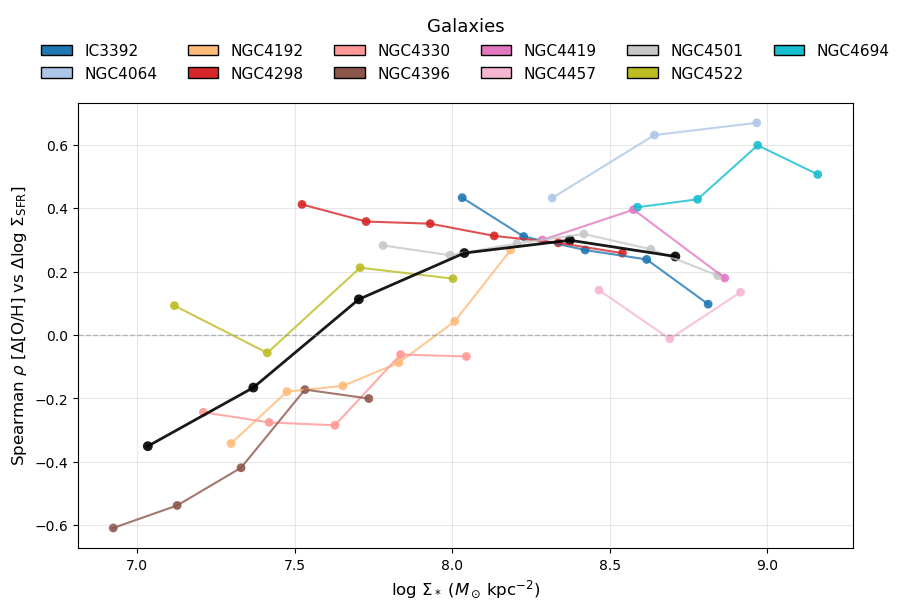

In [1]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 6 Σ_* bins for this galaxy (spanning 95% population)
    n_bins = 6
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using 3-sigma clipping on unique data (per galaxy)
    print("  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data
        # ------------------------------------------------------------------
        sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 0:
            # Get unique valid data using np.unique
            sfr_data = sfr_offset[valid_corr]
            oh_data = oh_offset[valid_corr]
            
            sfr_unique = np.unique(sfr_data)
            oh_unique = np.unique(oh_data)
            
            # Calculate mean and std on unique values
            x_mean = np.mean(sfr_unique)
            x_std = np.std(sfr_unique)
            y_mean = np.mean(oh_unique)
            y_std = np.std(oh_unique)
            
            # 3-sigma bounds
            x_lower = x_mean - 3 * x_std
            x_upper = x_mean + 3 * x_std
            y_lower = y_mean - 3 * y_std
            y_upper = y_mean + 3 * y_std
            
            # Apply 3-sigma clipping to all data points
            within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & \
                            (oh_data >= y_lower) & (oh_data <= y_upper)
            sigma_clip_mask[valid_corr] = within_3sigma

        # ------------------------------------------------------------------
        # Median trend using only points within 3-sigma
        # ------------------------------------------------------------------
        x_trend = sfr_offset[sigma_clip_mask]
        y_trend = oh_offset[sigma_clip_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Spearman rho: only for points within 3-sigma and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(sigma_clip_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(sfr_offset[sigma_clip_mask & valid_corr],
                                                oh_offset[sigma_clip_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f} (p={spearman_p:.3g})")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
        else:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 3σ)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 6 Σ_* bins for the combined sample (spanning 95% population)
    n_bins_global = 6
    sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
    sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data (global)
        # ------------------------------------------------------------------
        sigma_clip_mask_global = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 0:
            sfr_data_g = sfr_off_g[valid_corr_g]
            oh_data_g = oh_off_g[valid_corr_g]
            
            sfr_unique_g = np.unique(sfr_data_g)
            oh_unique_g = np.unique(oh_data_g)
            
            x_mean_g = np.mean(sfr_unique_g)
            x_std_g = np.std(sfr_unique_g)
            y_mean_g = np.mean(oh_unique_g)
            y_std_g = np.std(oh_unique_g)
            
            x_lower_g = x_mean_g - 3 * x_std_g
            x_upper_g = x_mean_g + 3 * x_std_g
            y_lower_g = y_mean_g - 3 * y_std_g
            y_upper_g = y_mean_g + 3 * y_std_g
            
            within_3sigma_g = (sfr_data_g >= x_lower_g) & (sfr_data_g <= x_upper_g) & \
                              (oh_data_g >= y_lower_g) & (oh_data_g <= y_upper_g)
            sigma_clip_mask_global[valid_corr_g] = within_3sigma_g

        x_trend_g = sfr_off_g[sigma_clip_mask_global]
        y_trend_g = oh_off_g[sigma_clip_mask_global]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(sigma_clip_mask_global & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(sfr_off_g[sigma_clip_mask_global & valid_corr_g],
                                     oh_off_g[sigma_clip_mask_global & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f} (p={p_g:.3g})")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 3σ)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    plotted_galaxies = [] # Keep track of which galaxies are actually plotted
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        
        # Filter: skip if only 1 data point
        if len(x_vals) <= 1:
            continue
            
        plotted_galaxies.append(gal_name)
        
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_rho_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    # ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in plotted_galaxies
    ]
    if len(plotted_galaxies) > 0:
        legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(plotted_galaxies), 6),
                        frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.png',
    #             dpi=600, bbox_inches='tight')
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.pdf',
    #             bbox_inches='tight')
    plt.show()
else:
    print("No valid Spearman rho values to plot.")

  IC3392: valid common HII pixels = 14906
  NGC4064: valid common HII pixels = 7077
  NGC4192: valid common HII pixels = 146165
  NGC4293: valid common HII pixels = 5715
  NGC4298: valid common HII pixels = 156571
  NGC4330: valid common HII pixels = 43026
  NGC4383: excluded from analysis
  NGC4396: valid common HII pixels = 81745
  NGC4419: valid common HII pixels = 7386
  NGC4457: valid common HII pixels = 6355
  NGC4501: valid common HII pixels = 261541
  NGC4522: valid common HII pixels = 39619
  NGC4694: valid common HII pixels = 2586
  NGC4698: valid common HII pixels = 10181

Total combined valid common HII pixels: 782873
95% enclosed points (rSFMS): 749320
95% enclosed points (rMZR):  752629
Shared mass-bin edges (6 bins, post-95%): [6.60494831 7.02710635 7.44926439 7.87142243 8.29358047 8.71573851
 9.13789655]
Shared bin width: 0.422 dex
rSFMS fit: m=0.7032, b=-7.9913
rMZR fit: a=8.5610, b=0.03587, c=8.0000


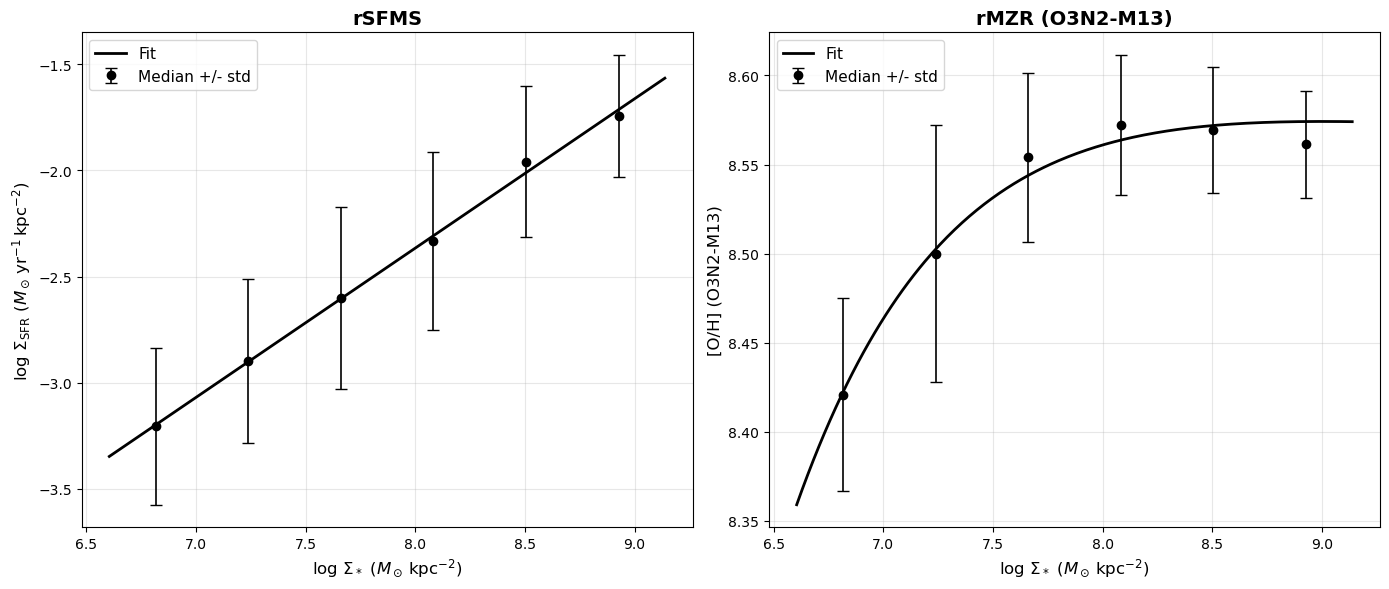


COMPLETED: Two-panel comparison (rSFMS + rMZR O3N2-M13, 95% enclosed first)
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383


In [2]:
# ------------------------------------------------------------------
# Two-panel comparison using shared stellar-mass bins (HII only)
#   Left : rSFMS  (log Sigma_* vs log Sigma_SFR)
#   Right: rMZR   (log Sigma_* vs [O/H] O3N2-M13)
# Workflow:
#   1) Enclose 95% population for each relation
#   2) Define shared 6 equal-width mass bins from enclosed populations
#   3) Do binning and fitting on enclosed points only
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from scipy.optimize import curve_fit
import scipy.ndimage as ndimage

def load_maps_sfms_mzr(gal):
    """Load maps needed for rSFMS and rMZR (O3N2-M13) for HII regions."""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h:
        sigM = h["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h:
        sigSFR_HII = h["LOGSFR_SURFACE_DENSITY_HII"].data
        oh_o3n2_m13_HII = h["O_H_O3N2_M13_HII"].data
    return sigM, sigSFR_HII, oh_o3n2_m13_HII

def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0):
    """Return mask for points inside the smoothed 95% density contour."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    full_mask = np.zeros_like(x_vals, dtype=bool)
    if not np.any(mask_finite):
        return full_mask

    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)

    H_flat = np.sort(H_smooth.ravel())[::-1]
    if H_flat.size == 0 or H_flat[0] <= 0:
        return full_mask

    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[min(level_idx, H_flat.size - 1)]

    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(
        H_smooth, [x_idx, y_idx], order=1, mode="constant", cval=0.0
    )
    local_mask = densities >= level_95
    full_mask[np.where(mask_finite)[0]] = local_mask
    return full_mask

def calculate_binned_stats_from_edges(x_data, y_data, bin_edges, min_unique=20):
    """Median/std in predefined x bins; keep bins with >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)
    finite = np.isfinite(x_data) & np.isfinite(y_data)

    centers = []
    medians = []
    stds = []
    counts = []

    for i in range(len(bin_edges) - 1):
        left = bin_edges[i]
        right = bin_edges[i + 1]
        if i == len(bin_edges) - 2:
            in_bin = finite & (x_data >= left) & (x_data <= right)
        else:
            in_bin = finite & (x_data >= left) & (x_data < right)

        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) < min_unique:
            continue

        centers.append(0.5 * (left + right))
        medians.append(np.nanmedian(y_in_bin))
        stds.append(np.nanstd(y_in_bin))
        counts.append(np.sum(in_bin))

    return np.array(centers), np.array(medians), np.array(stds), np.array(counts)

def line_model(x, m, b):
    return m * x + b

def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]
excluded_galaxies = {"NGC4383"}
included_galaxies = []

all_logSigmaM = []
all_logSigmaSFR = []
all_oh_o3n2_m13 = []

print("=" * 80)
print("Collecting data for rSFMS and rMZR (O3N2-M13), HII only...")
print("=" * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")
    if not (bin_file.exists() and gas_file.exists()):
        print(f"  {gal}: Data files not found")
        continue

    try:
        logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII = load_maps_sfms_mzr(gal)
    except Exception as e:
        print(f"  {gal}: failed to load maps ({e})")
        continue

    common_mask = np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII)
    n_valid = np.sum(common_mask)
    print(f"  {gal}: valid common HII pixels = {n_valid}")

    if n_valid == 0:
        continue

    included_galaxies.append(gal)
    all_logSigmaM.extend(logSigmaM[common_mask].ravel())
    all_logSigmaSFR.extend(logSigmaSFR_HII[common_mask].ravel())
    all_oh_o3n2_m13.extend(oh_o3n2_m13_HII[common_mask].ravel())

all_logSigmaM = np.array(all_logSigmaM)
all_logSigmaSFR = np.array(all_logSigmaSFR)
all_oh_o3n2_m13 = np.array(all_oh_o3n2_m13)

if all_logSigmaM.size == 0:
    raise RuntimeError("No valid common HII pixels found for plotting.")

print("\n" + "=" * 80)
print(f"Total combined valid common HII pixels: {all_logSigmaM.size}")
print("=" * 80)

# Enclose 95% population first (separately for each relation)
x_range = (np.nanmin(all_logSigmaM), np.nanmax(all_logSigmaM))
y_range_sfms = (np.nanmin(all_logSigmaSFR), np.nanmax(all_logSigmaSFR))
y_range_mzr = (np.nanmin(all_oh_o3n2_m13), np.nanmax(all_oh_o3n2_m13))

mask_95_sfms = compute_density_mask(all_logSigmaM, all_logSigmaSFR, x_range, y_range_sfms)
mask_95_mzr = compute_density_mask(all_logSigmaM, all_oh_o3n2_m13, x_range, y_range_mzr)

logSigmaM_sfms_95 = all_logSigmaM[mask_95_sfms]
logSigmaSFR_95 = all_logSigmaSFR[mask_95_sfms]
logSigmaM_mzr_95 = all_logSigmaM[mask_95_mzr]
oh_o3n2_m13_95 = all_oh_o3n2_m13[mask_95_mzr]

print(f"95% enclosed points (rSFMS): {logSigmaM_sfms_95.size}")
print(f"95% enclosed points (rMZR):  {logSigmaM_mzr_95.size}")

if logSigmaM_sfms_95.size == 0 or logSigmaM_mzr_95.size == 0:
    raise RuntimeError("95% population masking returned no points for one or both relations.")

# Shared 6 equal-width bins in stellar mass, defined AFTER enclosure
mass_for_bins = np.concatenate([logSigmaM_sfms_95, logSigmaM_mzr_95])
mass_min = np.nanmin(mass_for_bins)
mass_max = np.nanmax(mass_for_bins)
if not np.isfinite(mass_min) or not np.isfinite(mass_max) or mass_min == mass_max:
    raise RuntimeError("Invalid stellar-mass range after 95% enclosure; cannot define shared bins.")

n_bins = 6
mass_bin_edges = np.linspace(mass_min, mass_max, n_bins + 1)
bin_width = mass_bin_edges[1] - mass_bin_edges[0]
print(f"Shared mass-bin edges (6 bins, post-95%): {mass_bin_edges}")
print(f"Shared bin width: {bin_width:.3f} dex")

# Binned stats using the SAME bin edges for both relations, on 95%-enclosed points
sfms_centers, sfms_medians, sfms_stds, sfms_counts = calculate_binned_stats_from_edges(
    logSigmaM_sfms_95, logSigmaSFR_95, mass_bin_edges, min_unique=20
)
mzr_centers, mzr_medians, mzr_stds, mzr_counts = calculate_binned_stats_from_edges(
    logSigmaM_mzr_95, oh_o3n2_m13_95, mass_bin_edges, min_unique=20
)

# Fits on binned medians
x_fit = np.linspace(mass_bin_edges[0], mass_bin_edges[-1], 300)

fit_sfms_y = None
if sfms_centers.size >= 2:
    try:
        popt_sfms, _ = curve_fit(line_model, sfms_centers, sfms_medians, maxfev=5000)
        fit_sfms_y = line_model(x_fit, *popt_sfms)
        print(f"rSFMS fit: m={popt_sfms[0]:.4f}, b={popt_sfms[1]:.4f}")
    except Exception as e:
        print(f"rSFMS fit failed: {e}")
else:
    print("rSFMS fit skipped: insufficient binned points.")

fit_mzr_y = None
if mzr_centers.size >= 3:
    p0_mzr = [8.6, 0.01, 10.0]
    bounds_mzr = ([8.0, 0.0, 8.0], [9.2, 0.2, 12.5])
    try:
        popt_mzr, _ = curve_fit(
            mzr_model,
            mzr_centers,
            mzr_medians,
            p0=p0_mzr,
            bounds=bounds_mzr,
            maxfev=5000,
        )
        fit_mzr_y = mzr_model(x_fit, *popt_mzr)
        print(f"rMZR fit: a={popt_mzr[0]:.4f}, b={popt_mzr[1]:.5f}, c={popt_mzr[2]:.4f}")
    except Exception as e:
        print(f"rMZR fit failed: {e}")
else:
    print("rMZR fit skipped: insufficient binned points.")

# Plot (fit + std only)
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
plt.subplots_adjust(wspace=0.2)

# Left panel: rSFMS
if sfms_centers.size > 0:
    ax_left.errorbar(
        sfms_centers, sfms_medians, yerr=sfms_stds,
        fmt="o", color="k", markersize=6, linewidth=1.2, capsize=4,
        label="Median +/- std"
    )
if fit_sfms_y is not None:
    ax_left.plot(x_fit, fit_sfms_y, "k-", linewidth=2.0, label="Fit")

ax_left.set_title("rSFMS", fontsize=14, fontweight="bold")
ax_left.set_xlabel(r"$\log\,\Sigma_*\ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
ax_left.set_ylabel(r"$\log\,\Sigma_{\mathrm{SFR}}\ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$", fontsize=12)
ax_left.grid(True, alpha=0.3)
ax_left.legend(loc="best", fontsize=11)

# Right panel: rMZR (O3N2-M13)
if mzr_centers.size > 0:
    ax_right.errorbar(
        mzr_centers, mzr_medians, yerr=mzr_stds,
        fmt="o", color="k", markersize=6, linewidth=1.2, capsize=4,
        label="Median +/- std"
    )
if fit_mzr_y is not None:
    ax_right.plot(x_fit, fit_mzr_y, "k-", linewidth=2.0, label="Fit")

ax_right.set_title("rMZR (O3N2-M13)", fontsize=14, fontweight="bold")
ax_right.set_xlabel(r"$\log\,\Sigma_*\ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
ax_right.set_ylabel("[O/H] (O3N2-M13)", fontsize=12)
ax_right.grid(True, alpha=0.3)
ax_right.legend(loc="best", fontsize=11)

plt.tight_layout()
# plt.savefig("Plot_Paper_1/MAUVE_MUSE_rSFMS_rMZR_O3N2M13_shared6bins_95pop.png", dpi=600, bbox_inches="tight")
# plt.savefig("Plot_Paper_1/MAUVE_MUSE_rSFMS_rMZR_O3N2M13_shared6bins_95pop.pdf", bbox_inches="tight")
plt.show()

print("\n" + "=" * 80)
print("COMPLETED: Two-panel comparison (rSFMS + rMZR O3N2-M13, 95% enclosed first)")
print("=" * 80)
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")

Per-bin statistics using shared mass bins (95% intersection sample)
Bin            Mass range         N   Mass mean   Mass std    SFR mean    SFR std  [O/H] mean  [O/H] std
  1        [6.605, 7.027]     31997      6.9041     0.0920     -3.1363     0.3752      8.4256     0.0537
  2        [7.027, 7.449]     84852      7.2614     0.1208     -2.8910     0.3784      8.4879     0.0718
  3        [7.449, 7.871]    196686      7.6869     0.1202     -2.5847     0.4249      8.5507     0.0472
  4        [7.871, 8.294]    247212      8.0650     0.1183     -2.3069     0.4156      8.5724     0.0387
  5        [8.294, 8.716]    126267      8.4839     0.1212     -1.9438     0.3540      8.5701     0.0348
  6        [8.716, 9.138]     43333      8.8435     0.0901     -1.7247     0.2870      8.5618     0.0297


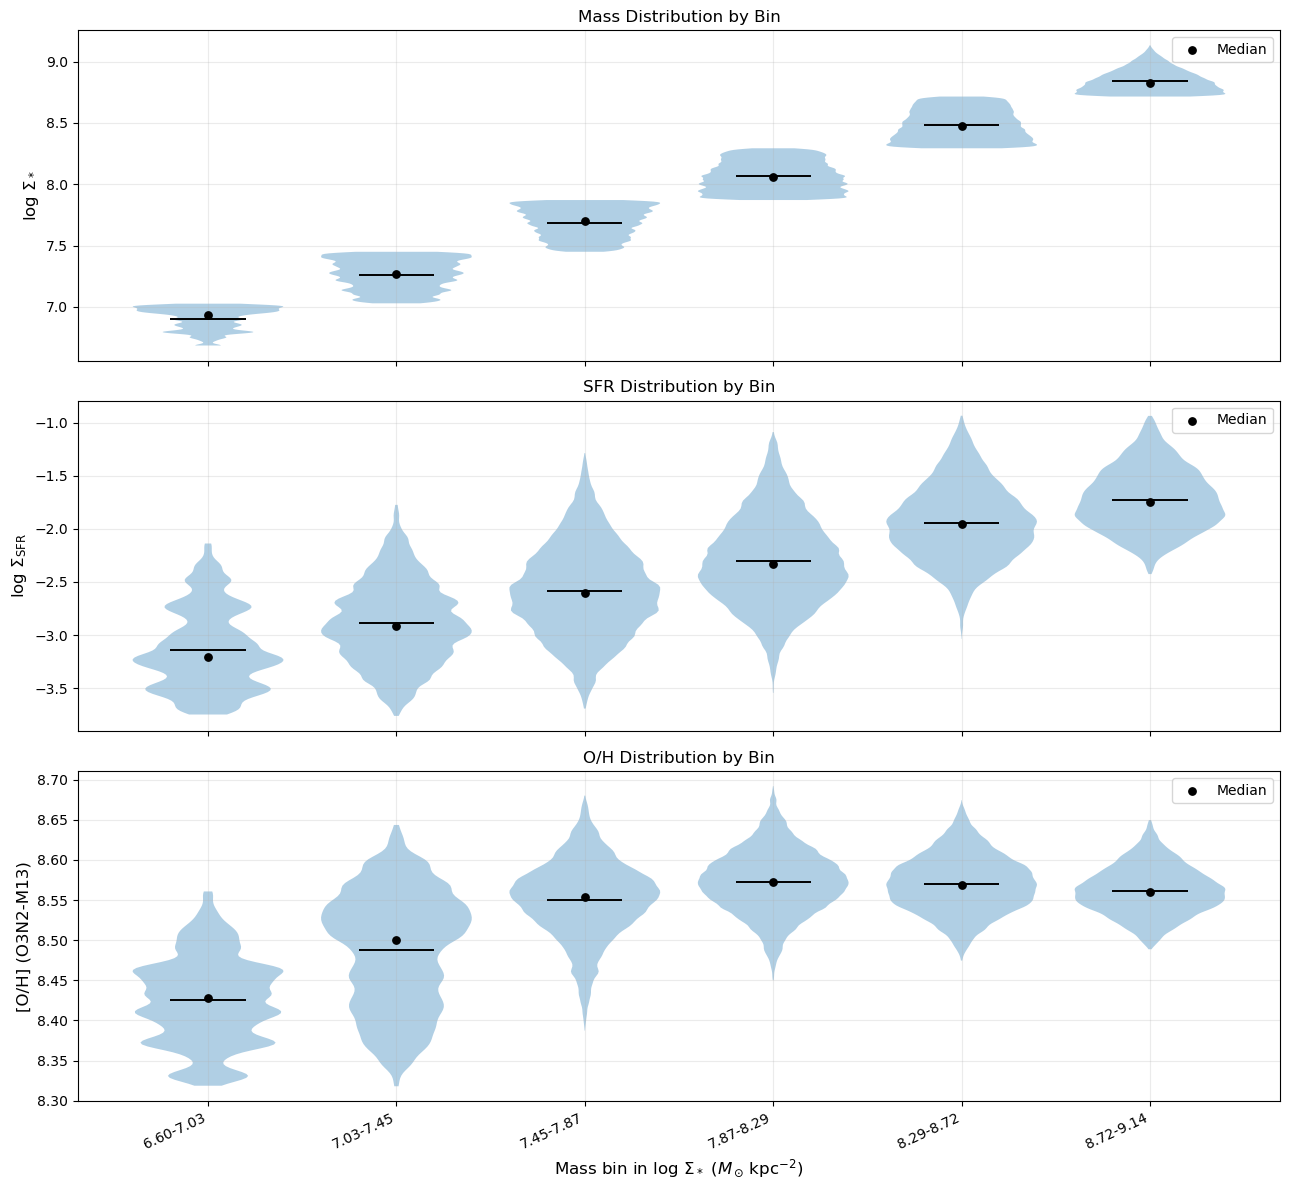

In [3]:
# ------------------------------------------------------------------
# Per-bin summary statistics and distribution visualization
# Uses the shared mass bins defined in Cell 2
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

required_vars = [
    "all_logSigmaM", "all_logSigmaSFR", "all_oh_o3n2_m13",
    "mask_95_sfms", "mask_95_mzr", "mass_bin_edges",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        "Run Cell 2 first. Missing variables: " + ", ".join(missing)
    )

# Use points enclosed by 95% in BOTH relations for consistent 3-variable stats
mask_95_common = mask_95_sfms & mask_95_mzr
mass_common = all_logSigmaM[mask_95_common]
sfr_common = all_logSigmaSFR[mask_95_common]
oh_common = all_oh_o3n2_m13[mask_95_common]

if mass_common.size == 0:
    raise RuntimeError("No points in the intersection of the two 95% masks.")

n_bins = len(mass_bin_edges) - 1

def mean_std(arr):
    if arr.size == 0:
        return np.nan, np.nan
    return np.nanmean(arr), np.nanstd(arr)

mass_by_bin = []
sfr_by_bin = []
oh_by_bin = []
rows = []

for i in range(n_bins):
    left = mass_bin_edges[i]
    right = mass_bin_edges[i + 1]
    if i == n_bins - 1:
        in_bin = (mass_common >= left) & (mass_common <= right)
    else:
        in_bin = (mass_common >= left) & (mass_common < right)

    m = mass_common[in_bin]
    s = sfr_common[in_bin]
    z = oh_common[in_bin]

    mass_by_bin.append(m)
    sfr_by_bin.append(s)
    oh_by_bin.append(z)

    m_mean, m_std = mean_std(m)
    s_mean, s_std = mean_std(s)
    z_mean, z_std = mean_std(z)

    rows.append([
        i + 1,
        f"[{left:.3f}, {right:.3f}]",
        m.size,
        m_mean, m_std,
        s_mean, s_std,
        z_mean, z_std,
    ])

print("=" * 120)
print("Per-bin statistics using shared mass bins (95% intersection sample)")
print("=" * 120)
print(
    f"{'Bin':>3}  {'Mass range':>20}  {'N':>8}  "
    f"{'Mass mean':>10} {'Mass std':>10}  "
    f"{'SFR mean':>10} {'SFR std':>10}  "
    f"{'[O/H] mean':>10} {'[O/H] std':>10}"
)
for r in rows:
    print(
        f"{r[0]:3d}  {r[1]:>20}  {r[2]:8d}  "
        f"{r[3]:10.4f} {r[4]:10.4f}  "
        f"{r[5]:10.4f} {r[6]:10.4f}  "
        f"{r[7]:10.4f} {r[8]:10.4f}"
    )
print("=" * 120)

# Visualize per-bin distributions
bin_positions = np.arange(1, n_bins + 1)
bin_labels = [f"{mass_bin_edges[i]:.2f}-{mass_bin_edges[i+1]:.2f}" for i in range(n_bins)]

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
plot_specs = [
    (mass_by_bin, r"$\log\,\Sigma_*$", "Mass Distribution by Bin"),
    (sfr_by_bin, r"$\log\,\Sigma_{\mathrm{SFR}}$", "SFR Distribution by Bin"),
    (oh_by_bin, "[O/H] (O3N2-M13)", "O/H Distribution by Bin"),
]

for ax, (data_by_bin, ylabel, title) in zip(axes, plot_specs):
    non_empty_idx = [i for i, d in enumerate(data_by_bin) if d.size > 0]
    if non_empty_idx:
        vp = ax.violinplot(
            [data_by_bin[i] for i in non_empty_idx],
            positions=[bin_positions[i] for i in non_empty_idx],
            showmeans=True,
            showextrema=False,
            widths=0.8,
        )
        for body in vp["bodies"]:
            body.set_alpha(0.35)
            body.set_facecolor("tab:blue")
        vp["cmeans"].set_color("black")
        vp["cmeans"].set_linewidth(1.4)

        medians = [np.nanmedian(data_by_bin[i]) for i in non_empty_idx]
        ax.scatter(
            [bin_positions[i] for i in non_empty_idx],
            medians,
            color="black",
            s=28,
            zorder=3,
            label="Median",
        )

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=10)

axes[-1].set_xticks(bin_positions)
axes[-1].set_xticklabels(bin_labels, rotation=25, ha="right")
axes[-1].set_xlabel(r"Mass bin in $\log\,\Sigma_*\ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)

plt.tight_layout()
plt.show()


Normality summary: log Sigma*
Bin         Range         N       mean        std    normaltest p    AD stat  AD crit(5%)  AD pass?
  1     6.60-7.03     31997     6.9041     0.0920       0.000e+00    846.618        0.787       N/A
  2     7.03-7.45     84852     7.2614     0.1208       0.000e+00    987.613        0.787       N/A
  3     7.45-7.87    196686     7.6869     0.1202       0.000e+00   2523.230        0.787       N/A
  4     7.87-8.29    247212     8.0650     0.1183       0.000e+00   2538.103        0.787       N/A
  5     8.29-8.72    126267     8.4839     0.1212       0.000e+00   1577.673        0.787       N/A
  6     8.72-9.14     43333     8.8435     0.0901       0.000e+00    571.727        0.787       N/A

Normality summary: log Sigma_SFR
Bin         Range         N       mean        std    normaltest p    AD stat  AD crit(5%)  AD pass?
  1     6.60-7.03     31997    -3.1363     0.3752       0.000e+00    353.023        0.787       N/A
  2     7.03-7.45     84852    -2.8

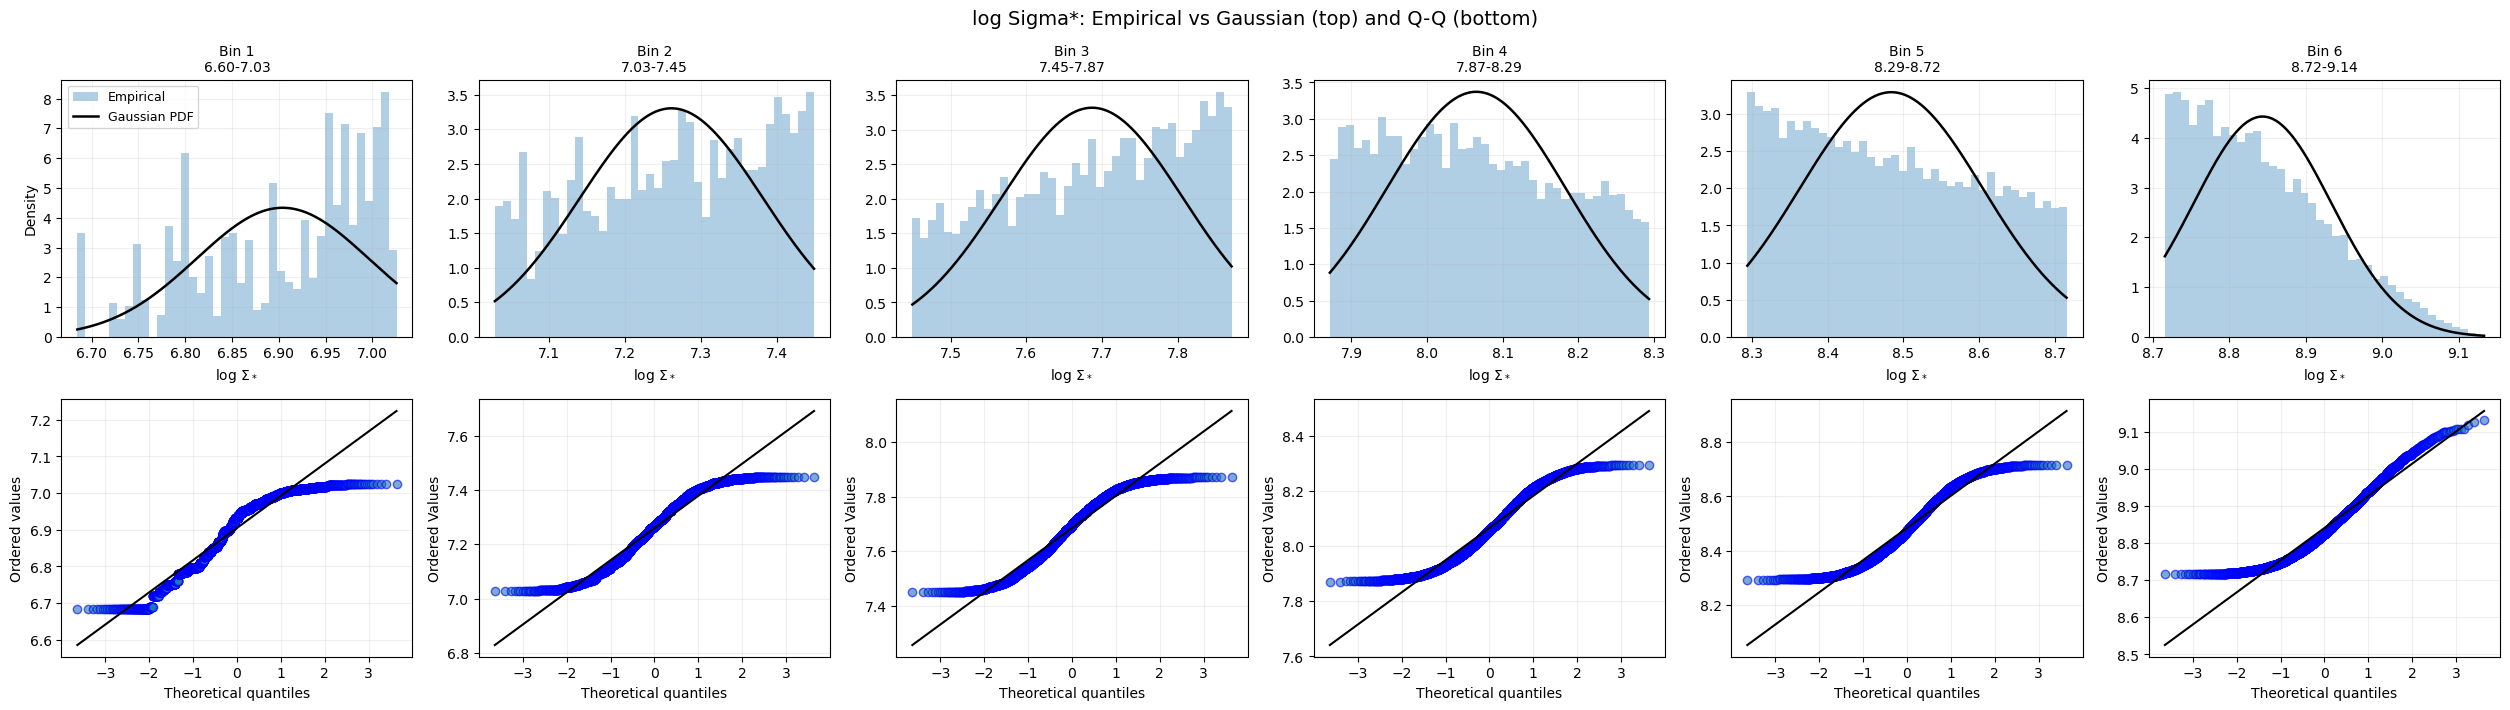

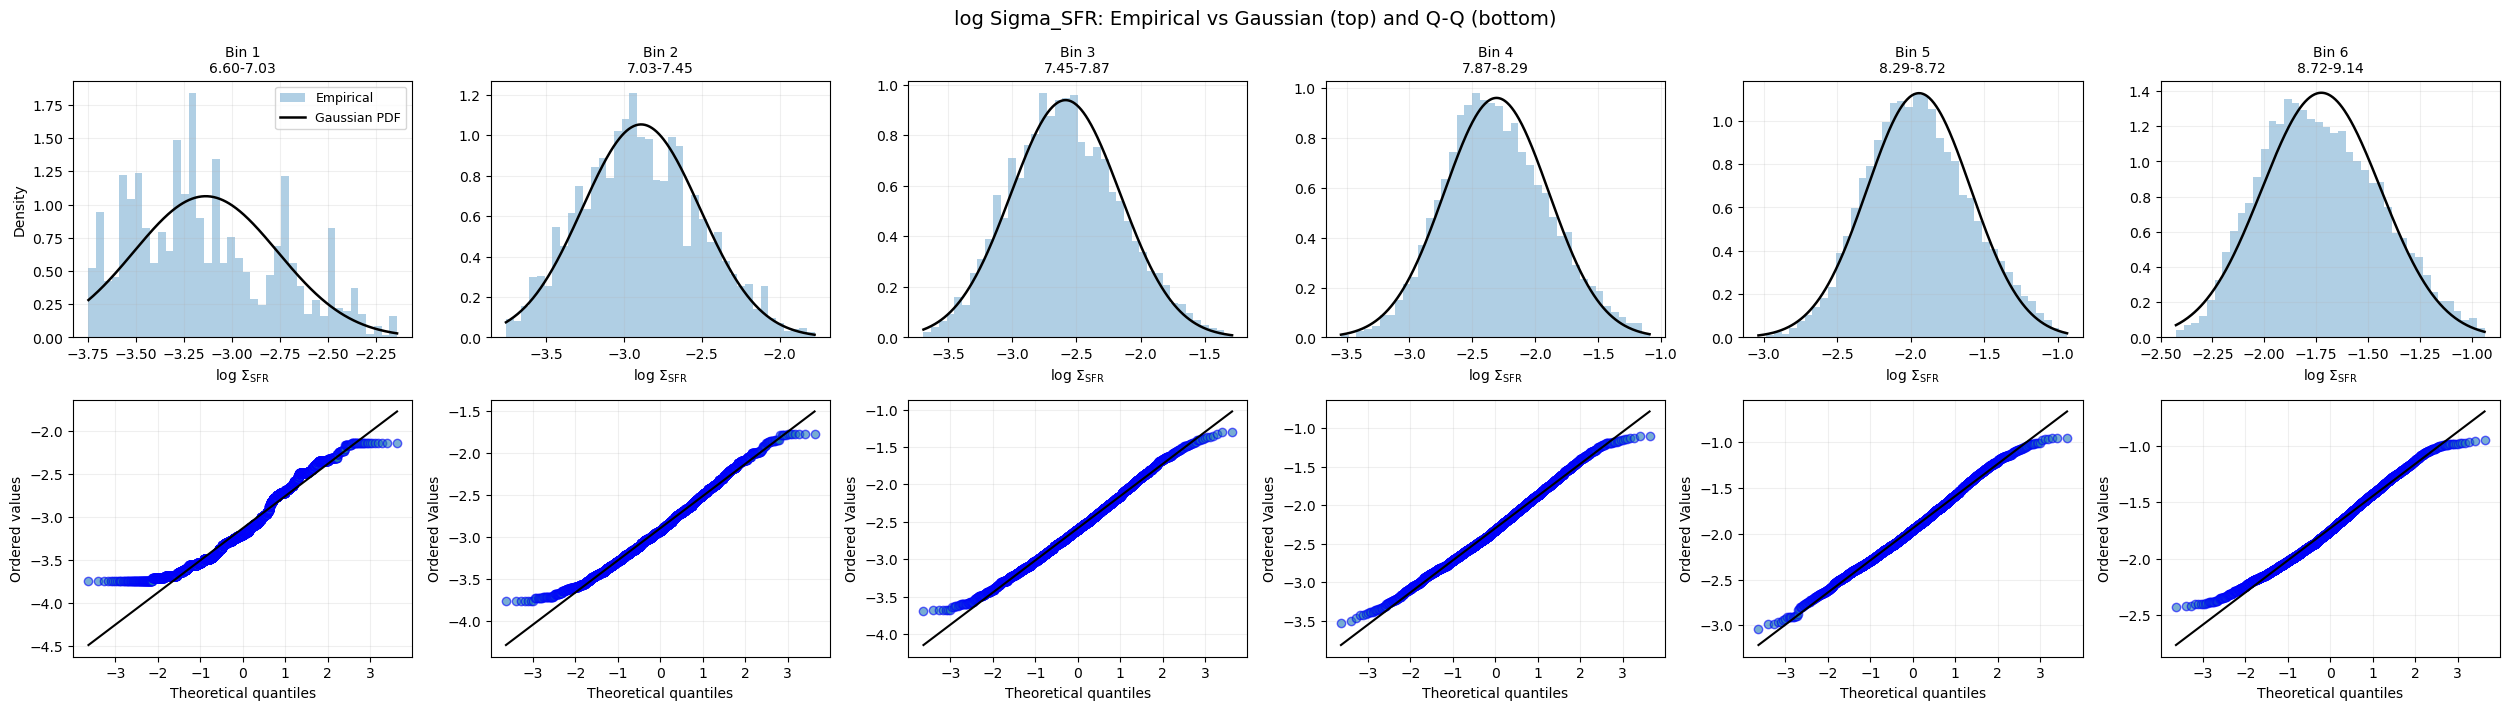

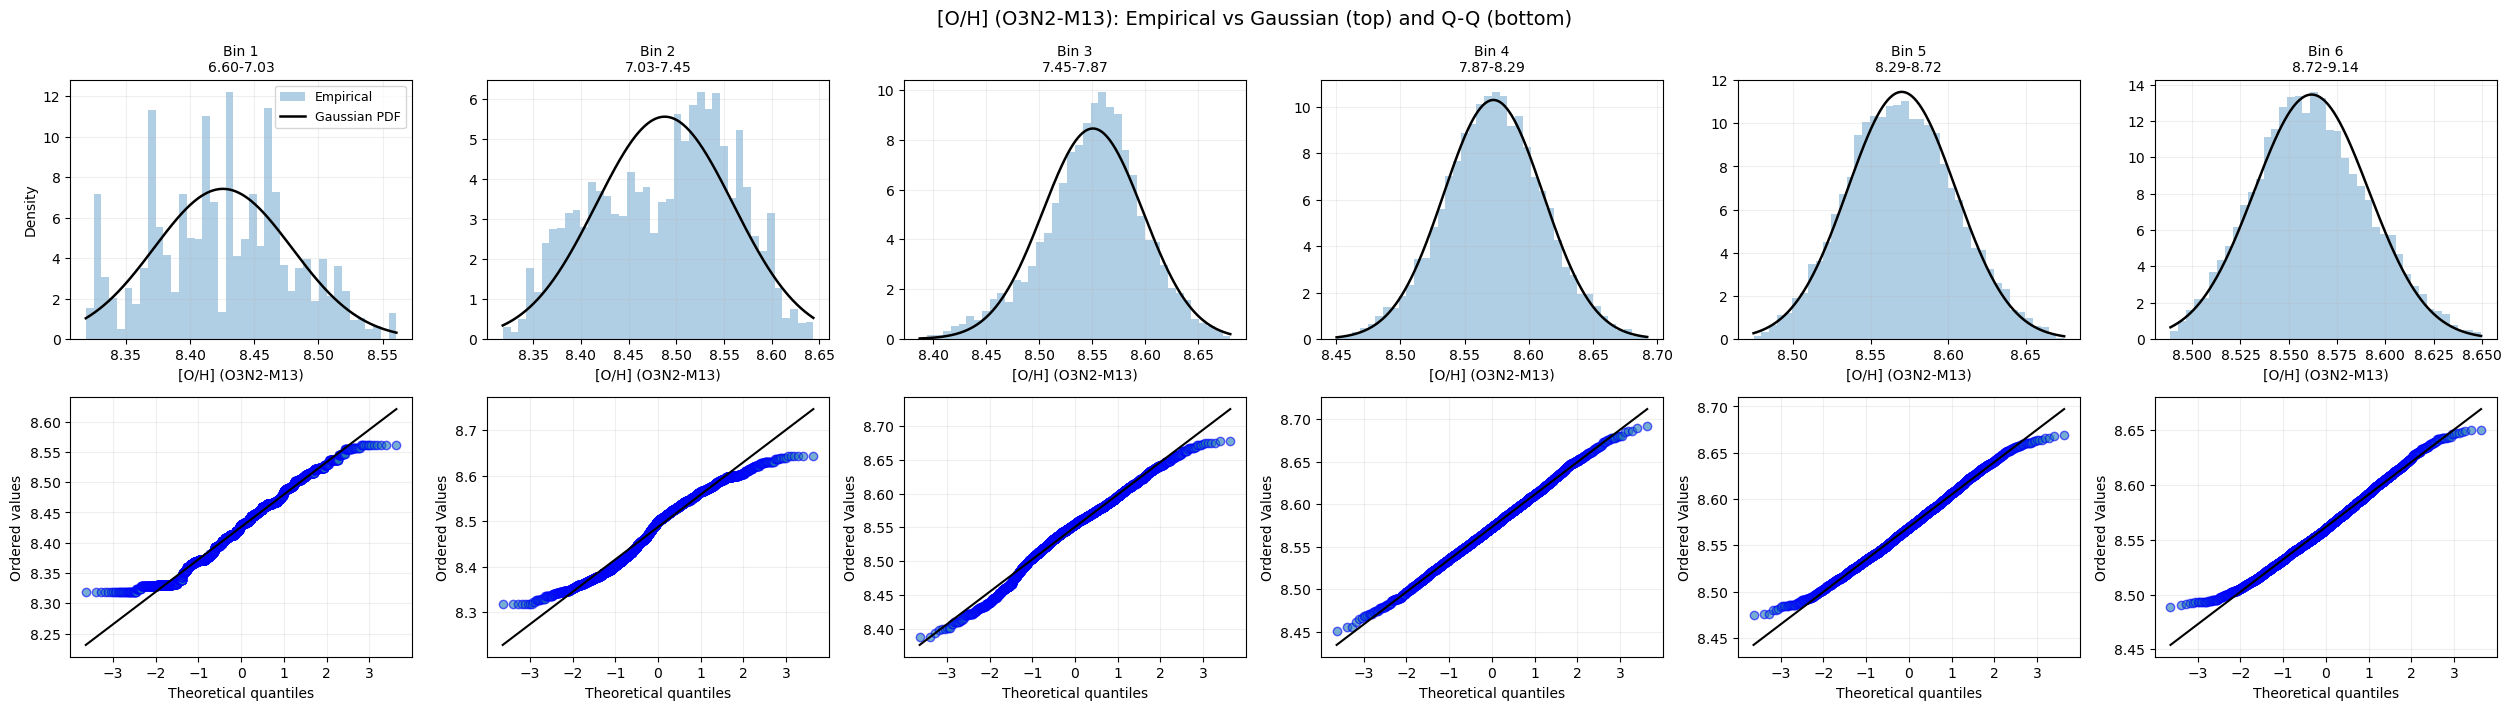


Note: with very large N, normality p-values can be extremely small even for mild deviations.


In [4]:
# ------------------------------------------------------------------
# Gaussianity check per mass bin: PDF overlays + Q-Q + tests
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot, normaltest, anderson

# Reuse bin-split arrays from Cell 3 when available; otherwise rebuild them.
if all(v in globals() for v in ["mass_by_bin", "sfr_by_bin", "oh_by_bin", "mass_bin_edges"]):
    pass
else:
    needed = ["all_logSigmaM", "all_logSigmaSFR", "all_oh_o3n2_m13", "mask_95_sfms", "mask_95_mzr", "mass_bin_edges"]
    missing = [v for v in needed if v not in globals()]
    if missing:
        raise RuntimeError("Run Cell 2 first. Missing variables: " + ", ".join(missing))

    mask_95_common = mask_95_sfms & mask_95_mzr
    mass_common = all_logSigmaM[mask_95_common]
    sfr_common = all_logSigmaSFR[mask_95_common]
    oh_common = all_oh_o3n2_m13[mask_95_common]

    n_bins = len(mass_bin_edges) - 1
    mass_by_bin, sfr_by_bin, oh_by_bin = [], [], []
    for i in range(n_bins):
        left, right = mass_bin_edges[i], mass_bin_edges[i + 1]
        if i == n_bins - 1:
            in_bin = (mass_common >= left) & (mass_common <= right)
        else:
            in_bin = (mass_common >= left) & (mass_common < right)
        mass_by_bin.append(mass_common[in_bin])
        sfr_by_bin.append(sfr_common[in_bin])
        oh_by_bin.append(oh_common[in_bin])

n_bins = len(mass_bin_edges) - 1
bin_labels = [f"{mass_bin_edges[i]:.2f}-{mass_bin_edges[i+1]:.2f}" for i in range(n_bins)]

def summarize_normality(data_by_bin, quantity_name):
    """Print normality metrics per bin for one quantity."""
    print("\n" + "=" * 120)
    print(f"Normality summary: {quantity_name}")
    print("=" * 120)
    print(
        f"{'Bin':>3}  {'Range':>12}  {'N':>8}  {'mean':>9}  {'std':>9}  "
        f"{'normaltest p':>14}  {'AD stat':>9}  {'AD crit(5%)':>11}  {'AD pass?':>8}"
)

    for i, arr in enumerate(data_by_bin):
        arr = np.asarray(arr)
        arr = arr[np.isfinite(arr)]
        n = arr.size
        if n < 8:
            print(f"{i+1:3d}  {bin_labels[i]:>12}  {n:8d}  {'N/A':>9}  {'N/A':>9}  {'N/A':>14}  {'N/A':>9}  {'N/A':>11}  {'N/A':>8}")
            continue

        mu = np.mean(arr)
        sig = np.std(arr)

        try:
            _, p_norm = normaltest(arr)
        except Exception:
            p_norm = np.nan

        try:
            ad_res = anderson(arr, dist="norm")
            ad_stat = ad_res.statistic
            # significance_level is [15,10,5,2.5,1]; pick 5%
            idx_5 = list(ad_res.significance_level).index(5.0)
            ad_crit_5 = ad_res.critical_values[idx_5]
            ad_pass = ad_stat < ad_crit_5
        except Exception:
            ad_stat, ad_crit_5, ad_pass = np.nan, np.nan, None

        pass_str = "Yes" if ad_pass is True else ("No" if ad_pass is False else "N/A")
        p_str = f"{p_norm:.3e}" if np.isfinite(p_norm) else "N/A"
        ad_stat_str = f"{ad_stat:.3f}" if np.isfinite(ad_stat) else "N/A"
        ad_crit_str = f"{ad_crit_5:.3f}" if np.isfinite(ad_crit_5) else "N/A"

        print(
            f"{i+1:3d}  {bin_labels[i]:>12}  {n:8d}  {mu:9.4f}  {sig:9.4f}  "
            f"{p_str:>14}  {ad_stat_str:>9}  {ad_crit_str:>11}  {pass_str:>8}"
        )

def plot_pdf_and_qq(data_by_bin, quantity_name, x_label):
    """For each bin: top=empirical histogram+Gaussian PDF, bottom=Q-Q plot."""
    fig, axes = plt.subplots(2, n_bins, figsize=(4.2 * n_bins, 7.2))
    rng = np.random.default_rng(42)

    for i, arr in enumerate(data_by_bin):
        arr = np.asarray(arr)
        arr = arr[np.isfinite(arr)]
        ax_pdf = axes[0, i]
        ax_qq = axes[1, i]

        ax_pdf.set_title(f"Bin {i+1}\n{bin_labels[i]}", fontsize=10)

        if arr.size < 8:
            ax_pdf.text(0.5, 0.5, "N < 8", ha="center", va="center", transform=ax_pdf.transAxes)
            ax_qq.text(0.5, 0.5, "N < 8", ha="center", va="center", transform=ax_qq.transAxes)
            ax_pdf.grid(True, alpha=0.2)
            ax_qq.grid(True, alpha=0.2)
            continue

        mu = np.mean(arr)
        sig = np.std(arr)

        # Histogram + fitted Gaussian PDF
        ax_pdf.hist(arr, bins=40, density=True, alpha=0.35, color="tab:blue", edgecolor="none", label="Empirical")
        if sig > 0:
            x = np.linspace(np.min(arr), np.max(arr), 400)
            ax_pdf.plot(x, norm.pdf(x, loc=mu, scale=sig), color="black", lw=1.8, label="Gaussian PDF")
        ax_pdf.grid(True, alpha=0.2)

        # Q-Q plot: subsample for speed/visibility on very large N
        if arr.size > 5000:
            arr_for_qq = rng.choice(arr, size=5000, replace=False)
        else:
            arr_for_qq = arr
        probplot(arr_for_qq, dist="norm", plot=ax_qq)
        ax_qq.grid(True, alpha=0.2)
        ax_qq.set_title("")
        ax_qq.get_lines()[0].set_markerfacecolor("tab:blue")
        ax_qq.get_lines()[0].set_alpha(0.6)
        ax_qq.get_lines()[1].set_color("black")

    axes[0, 0].set_ylabel("Density")
    axes[1, 0].set_ylabel("Ordered values")
    for i in range(n_bins):
        axes[0, i].set_xlabel(x_label)
        axes[1, i].set_xlabel("Theoretical quantiles")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        axes[0, 0].legend(loc="best", fontsize=9)
    fig.suptitle(f"{quantity_name}: Empirical vs Gaussian (top) and Q-Q (bottom)", fontsize=14)
    plt.tight_layout()
    plt.show()

# Run reports and plots
summarize_normality(mass_by_bin, "log Sigma*")
summarize_normality(sfr_by_bin, "log Sigma_SFR")
summarize_normality(oh_by_bin, "[O/H] (O3N2-M13)")

plot_pdf_and_qq(mass_by_bin, "log Sigma*", r"$\log\,\Sigma_*$")
plot_pdf_and_qq(sfr_by_bin, "log Sigma_SFR", r"$\log\,\Sigma_{\mathrm{SFR}}$")
plot_pdf_and_qq(oh_by_bin, "[O/H] (O3N2-M13)", "[O/H] (O3N2-M13)")

print("\nNote: with very large N, normality p-values can be extremely small even for mild deviations.")

### Null Hypothesis: Simple Gaussian Simulation

**Goal**: Assess if the observed SFR-Metallicity rank correlations ($\rho$) could simply result from random, independent sampling of their underlying un-correlated distributions within each stellar mass bin.

**Methodology**:
1. **Empirical Statistics**: For each shared stellar mass bin ($\log\,\Sigma_*$), we calculate the sample mean ($\mu$) and standard deviation ($\sigma$) of the observed Star Formation Rate ($\log\,\Sigma_{\mathrm{SFR}}$) and Metallicity ($\text{[O/H]}$).
2. **Independent Random Draws**: We generate a large mock dataset ($N=1,000,000$ draws per bin). Crucially, SFR and Metallicity are drawn **independently** from two un-correlated, normally distributed populations based on our observed parameters: $\mathcal{N}(\mu_{\mathrm{SFR}}, \sigma_{\mathrm{SFR}})$ and $\mathcal{N}(\mu_{\mathrm{O/H}}, \sigma_{\mathrm{O/H}})$.
3. **Correlation Check**: Next, we compute the Spearman rank correlation coefficient ($\rho$) on the simulated datasets in each bin. Since the random variables are drawn independently, this acts as our expected null-correlation baseline.
4. **Comparison**: By comparing the simulated correlations (which should bounce around zero) with the true observed ensemble trend, we can confidently determine whether the observed relations are driven by actual physical dependence between SFR and O/H.

Gaussian simulation complete (seed=726, draws per bin=1000000)
Columns: observed mean/std and simulated mean/std for SFR and O/H
Bin  Mass range     N_obs  SFR obs mu SFR obs sd SFR sim mu SFR sim sd   OH obs mu  OH obs sd  OH sim mu  OH sim sd
  1   6.60-7.03     31997     -3.1363     0.3752    -3.1370     0.3748      8.4256     0.0537     8.4256     0.0538
  2   7.03-7.45     84852     -2.8910     0.3784    -2.8905     0.3780      8.4879     0.0718     8.4879     0.0718
  3   7.45-7.87    196686     -2.5847     0.4249    -2.5846     0.4251      8.5507     0.0472     8.5507     0.0472
  4   7.87-8.29    247212     -2.3069     0.4156    -2.3073     0.4156      8.5724     0.0387     8.5724     0.0388
  5   8.29-8.72    126267     -1.9438     0.3540    -1.9442     0.3536      8.5701     0.0348     8.5701     0.0348
  6   8.72-9.14     43333     -1.7247     0.2870    -1.7248     0.2870      8.5618     0.0297     8.5619     0.0297
Saved outputs:
  - sim_sfr_by_bin, sim_oh_by_bin, sim_point

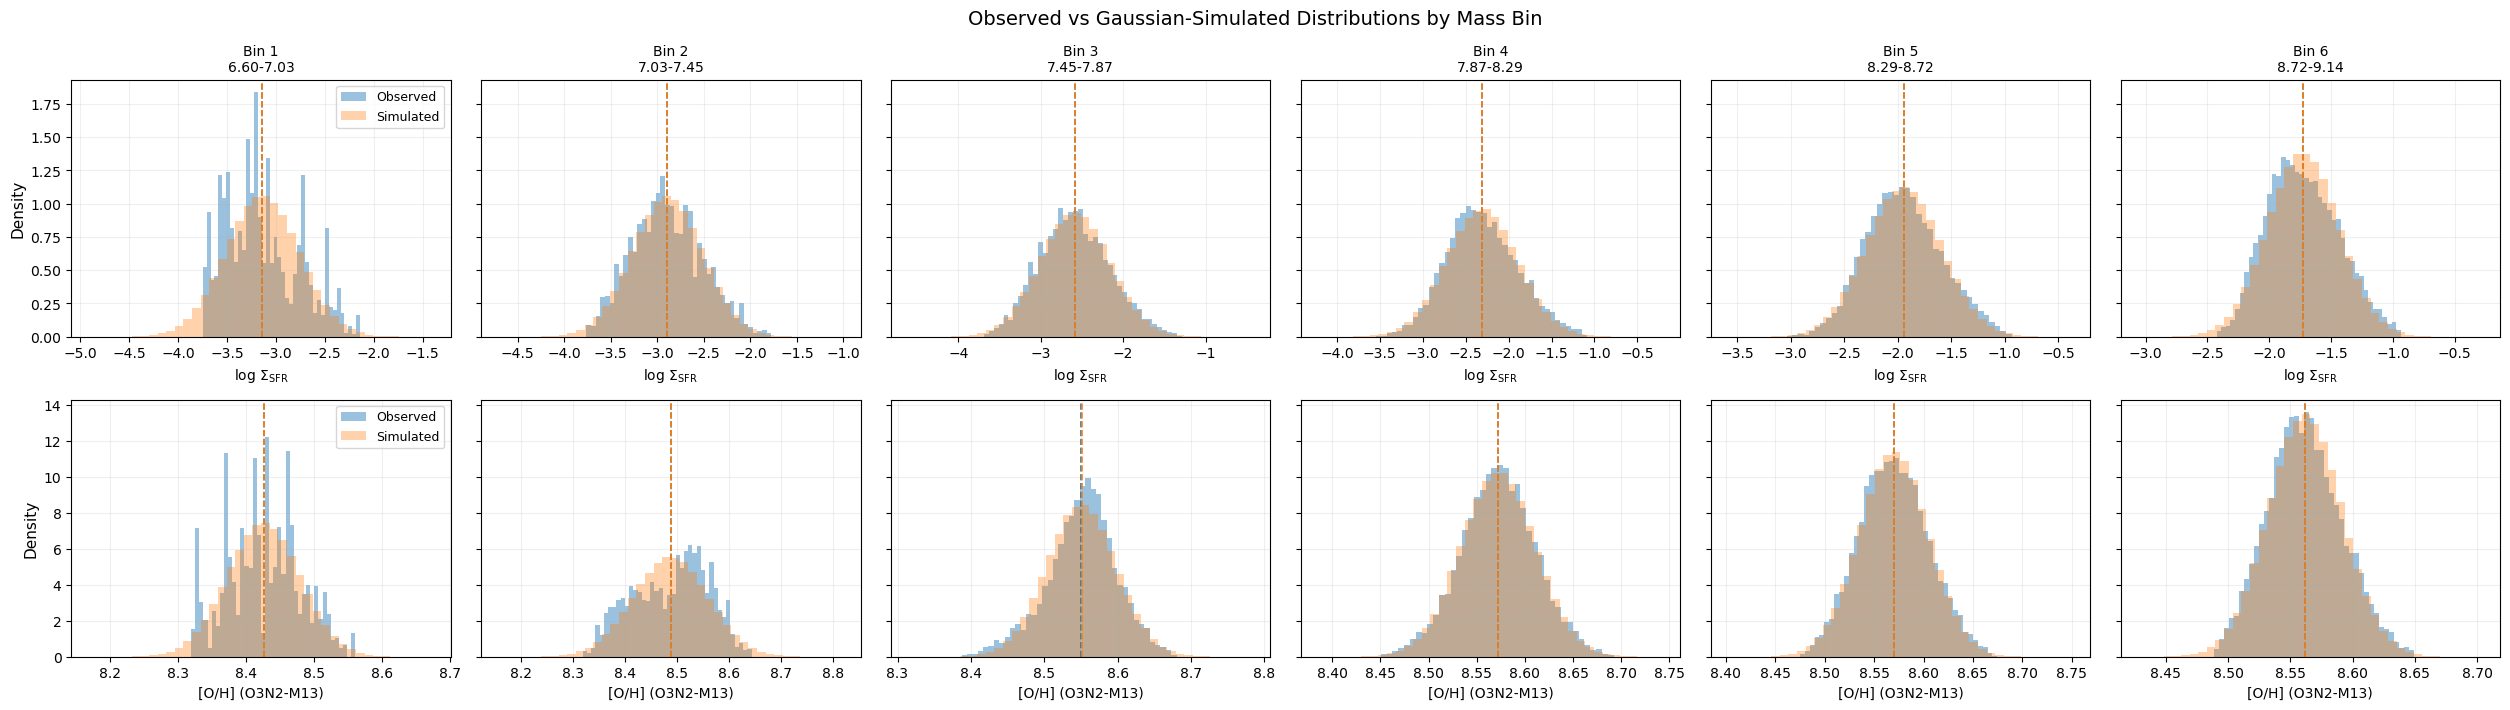

In [5]:
# ------------------------------------------------------------------
# Simple Gaussian simulation per mass bin (SFR and O/H)
# Using observed mean/std in each bin and random seed = 726
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

SEED = 726
N_SIM = 1000000
rng = np.random.default_rng(SEED)

# Try to reuse bin-split arrays from previous cells; rebuild only if missing.
if all(v in globals() for v in ["sfr_by_bin", "oh_by_bin", "mass_bin_edges"]):
    pass
else:
    needed = ["all_logSigmaM", "all_logSigmaSFR", "all_oh_o3n2_m13", "mask_95_sfms", "mask_95_mzr", "mass_bin_edges"]
    missing = [v for v in needed if v not in globals()]
    if missing:
        raise RuntimeError("Run Cell 2 first. Missing variables: " + ", ".join(missing))

    mask_95_common = mask_95_sfms & mask_95_mzr
    mass_common = all_logSigmaM[mask_95_common]
    sfr_common = all_logSigmaSFR[mask_95_common]
    oh_common = all_oh_o3n2_m13[mask_95_common]

    n_bins = len(mass_bin_edges) - 1
    sfr_by_bin = []
    oh_by_bin = []
    for i in range(n_bins):
        left, right = mass_bin_edges[i], mass_bin_edges[i + 1]
        if i == n_bins - 1:
            in_bin = (mass_common >= left) & (mass_common <= right)
        else:
            in_bin = (mass_common >= left) & (mass_common < right)
        sfr_by_bin.append(sfr_common[in_bin])
        oh_by_bin.append(oh_common[in_bin])

n_bins = len(mass_bin_edges) - 1
bin_labels = [f"{mass_bin_edges[i]:.2f}-{mass_bin_edges[i+1]:.2f}" for i in range(n_bins)]

sim_sfr_by_bin = []
sim_oh_by_bin = []
sim_points_by_bin = []  # each element shape: (N_SIM, 2) columns=[SFR, O/H]
sim_summary = []

for i in range(n_bins):
    obs_sfr = np.asarray(sfr_by_bin[i])
    obs_oh = np.asarray(oh_by_bin[i])
    obs_sfr = obs_sfr[np.isfinite(obs_sfr)]
    obs_oh = obs_oh[np.isfinite(obs_oh)]

    if obs_sfr.size == 0 or obs_oh.size == 0:
        sim_sfr = np.array([])
        sim_oh = np.array([])
        sim_points = np.empty((0, 2))
        sim_summary.append([
            i + 1, bin_labels[i], 0,
            np.nan, np.nan, np.nan, np.nan,
            np.nan, np.nan, np.nan, np.nan,
        ])
    else:
        mu_sfr = np.mean(obs_sfr)
        sd_sfr = np.std(obs_sfr)
        mu_oh = np.mean(obs_oh)
        sd_oh = np.std(obs_oh)

        # Gaussian draws per bin
        sim_sfr = rng.normal(loc=mu_sfr, scale=sd_sfr, size=N_SIM) if sd_sfr > 0 else np.full(N_SIM, mu_sfr)
        sim_oh = rng.normal(loc=mu_oh, scale=sd_oh, size=N_SIM) if sd_oh > 0 else np.full(N_SIM, mu_oh)
        sim_points = np.column_stack([sim_sfr, sim_oh])

        sim_summary.append([
            i + 1, bin_labels[i], obs_sfr.size,
            mu_sfr, sd_sfr, np.mean(sim_sfr), np.std(sim_sfr),
            mu_oh, sd_oh, np.mean(sim_oh), np.std(sim_oh),
        ])

    sim_sfr_by_bin.append(sim_sfr)
    sim_oh_by_bin.append(sim_oh)
    sim_points_by_bin.append(sim_points)

# Store in a single container for downstream analysis
gaussian_simulation = {
    "seed": SEED,
    "n_per_bin": N_SIM,
    "mass_bin_edges": mass_bin_edges.copy(),
    "bin_labels": bin_labels,
    "sim_sfr_by_bin": sim_sfr_by_bin,
    "sim_oh_by_bin": sim_oh_by_bin,
    "sim_points_by_bin": sim_points_by_bin,
}

print("=" * 140)
print(f"Gaussian simulation complete (seed={SEED}, draws per bin={N_SIM})")
print("Columns: observed mean/std and simulated mean/std for SFR and O/H")
print("=" * 140)
print(
    f"{'Bin':>3}  {'Mass range':>10}  {'N_obs':>8}  "
    f"{'SFR obs mu':>10} {'SFR obs sd':>10} {'SFR sim mu':>10} {'SFR sim sd':>10}  "
    f"{'OH obs mu':>10} {'OH obs sd':>10} {'OH sim mu':>10} {'OH sim sd':>10}"
)
for r in sim_summary:
    print(
        f"{r[0]:3d}  {r[1]:>10}  {r[2]:8d}  "
        f"{r[3]:10.4f} {r[4]:10.4f} {r[5]:10.4f} {r[6]:10.4f}  "
        f"{r[7]:10.4f} {r[8]:10.4f} {r[9]:10.4f} {r[10]:10.4f}"
    )
print("=" * 140)
print("Saved outputs:")
print("  - sim_sfr_by_bin, sim_oh_by_bin, sim_points_by_bin")
print("  - gaussian_simulation dict")

# ------------------------------------------------------------------
# Visualization: simulated vs observed distribution in each mass bin
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, n_bins, figsize=(4.2 * n_bins, 7.2), sharey='row')

for i in range(n_bins):
    obs_sfr = np.asarray(sfr_by_bin[i])
    sim_sfr = np.asarray(sim_sfr_by_bin[i])
    obs_oh = np.asarray(oh_by_bin[i])
    sim_oh = np.asarray(sim_oh_by_bin[i])

    obs_sfr = obs_sfr[np.isfinite(obs_sfr)]
    sim_sfr = sim_sfr[np.isfinite(sim_sfr)]
    obs_oh = obs_oh[np.isfinite(obs_oh)]
    sim_oh = sim_oh[np.isfinite(sim_oh)]

    ax_sfr = axes[0, i]
    ax_oh = axes[1, i]
    ax_sfr.set_title(f"Bin {i+1}\n{bin_labels[i]}", fontsize=10)

    if obs_sfr.size > 0 and sim_sfr.size > 0:
        ax_sfr.hist(obs_sfr, bins=40, density=True, alpha=0.45, color="tab:blue", label="Observed")
        ax_sfr.hist(sim_sfr, bins=40, density=True, alpha=0.35, color="tab:orange", label="Simulated")
        ax_sfr.axvline(np.mean(obs_sfr), color="tab:blue", linestyle="--", linewidth=1.2)
        ax_sfr.axvline(np.mean(sim_sfr), color="tab:orange", linestyle="--", linewidth=1.2)
    else:
        ax_sfr.text(0.5, 0.5, "No data", transform=ax_sfr.transAxes, ha="center", va="center")
    ax_sfr.grid(True, alpha=0.2)

    if obs_oh.size > 0 and sim_oh.size > 0:
        ax_oh.hist(obs_oh, bins=40, density=True, alpha=0.45, color="tab:blue", label="Observed")
        ax_oh.hist(sim_oh, bins=40, density=True, alpha=0.35, color="tab:orange", label="Simulated")
        ax_oh.axvline(np.mean(obs_oh), color="tab:blue", linestyle="--", linewidth=1.2)
        ax_oh.axvline(np.mean(sim_oh), color="tab:orange", linestyle="--", linewidth=1.2)
    else:
        ax_oh.text(0.5, 0.5, "No data", transform=ax_oh.transAxes, ha="center", va="center")
    ax_oh.grid(True, alpha=0.2)

axes[0, 0].set_ylabel("Density", fontsize=11)
axes[1, 0].set_ylabel("Density", fontsize=11)
for i in range(n_bins):
    axes[0, i].set_xlabel(r"$\log\,\Sigma_{\mathrm{SFR}}$", fontsize=10)
    axes[1, i].set_xlabel("[O/H] (O3N2-M13)", fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    axes[0, 0].legend(loc="best", fontsize=9)
handles2, labels2 = axes[1, 0].get_legend_handles_labels()
if handles2:
    axes[1, 0].legend(loc="best", fontsize=9)

fig.suptitle("Observed vs Gaussian-Simulated Distributions by Mass Bin", fontsize=14)
plt.tight_layout()
plt.show()

Spearman rho in each mass bin: Simulated Gaussian vs Original Observed
Bin  Mass range   <logSigma*>     rho_sim         p_sim  |     rho_obs         p_obs
  1  6.60-7.03        6.9041      0.0008     4.240e-01  |     -0.2934     0.000e+00
  2  7.03-7.45        7.2614      0.0008     4.080e-01  |     -0.1674     0.000e+00
  3  7.45-7.87        7.6869     -0.0013     1.916e-01  |      0.1012     0.000e+00
  4  7.87-8.29        8.0650      0.0006     5.717e-01  |      0.2505     0.000e+00
  5  8.29-8.72        8.4839     -0.0000     9.885e-01  |      0.2598     0.000e+00
  6  8.72-9.14        8.8435      0.0001     8.818e-01  |      0.1445    7.147e-201


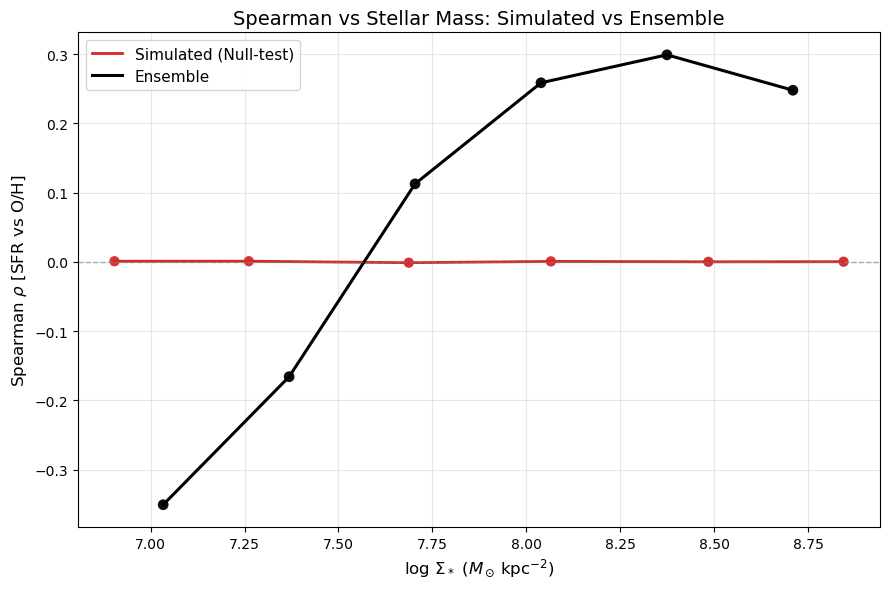

In [6]:
# ------------------------------------------------------------------
# Spearman rho from simulated data per mass bin
# Compare against ensemble black curve from Cell 1
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

required = ["sim_sfr_by_bin", "sim_oh_by_bin", "mass_bin_edges", "global_bin_centers", "global_rho_values"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError("Missing variables. Run Cells 1, 2, and 5 first: " + ", ".join(missing))

# Mean stellar mass for each bin (use observed mass_by_bin if available, else bin-center)
sim_mass_means = []
if "mass_by_bin" in globals() and len(mass_by_bin) == len(mass_bin_edges) - 1:
    for i in range(len(mass_by_bin)):
        arr = np.asarray(mass_by_bin[i])
        arr = arr[np.isfinite(arr)]
        if arr.size > 0:
            sim_mass_means.append(np.nanmean(arr))
        else:
            sim_mass_means.append(0.5 * (mass_bin_edges[i] + mass_bin_edges[i + 1]))
else:
    for i in range(len(mass_bin_edges) - 1):
        sim_mass_means.append(0.5 * (mass_bin_edges[i] + mass_bin_edges[i + 1]))
sim_mass_means = np.array(sim_mass_means)

sim_spearman_rho = []
sim_spearman_p = []
obs_spearman_rho = []
obs_spearman_p = []
for i, (sfr_sim, oh_sim, sfr_obs, oh_obs) in enumerate(zip(sim_sfr_by_bin, sim_oh_by_bin, sfr_by_bin, oh_by_bin)):
    # Simulated
    sfr_sim = np.asarray(sfr_sim)
    oh_sim = np.asarray(oh_sim)
    valid_sim = np.isfinite(sfr_sim) & np.isfinite(oh_sim)
    if np.sum(valid_sim) > 2:
        rho_s, p_s = spearmanr(sfr_sim[valid_sim], oh_sim[valid_sim])
    else:
        rho_s, p_s = np.nan, np.nan
    sim_spearman_rho.append(rho_s)
    sim_spearman_p.append(p_s)
    
    # Observed
    sfr_obs = np.asarray(sfr_obs)
    oh_obs = np.asarray(oh_obs)
    valid_obs = np.isfinite(sfr_obs) & np.isfinite(oh_obs)
    if np.sum(valid_obs) > 2:
        rho_o, p_o = spearmanr(sfr_obs[valid_obs], oh_obs[valid_obs])
    else:
        rho_o, p_o = np.nan, np.nan
    obs_spearman_rho.append(rho_o)
    obs_spearman_p.append(p_o)

sim_spearman_rho = np.array(sim_spearman_rho)
sim_spearman_p = np.array(sim_spearman_p)
obs_spearman_rho = np.array(obs_spearman_rho)
obs_spearman_p = np.array(obs_spearman_p)

print("=" * 125)
print("Spearman rho in each mass bin: Simulated Gaussian vs Original Observed")
print("=" * 125)
print(f"{'Bin':>3}  {'Mass range':>10}  {'<logSigma*>':>12}  {'rho_sim':>10}  {'p_sim':>12}  |  {'rho_obs':>10}  {'p_obs':>12}")
for i in range(len(sim_spearman_rho)):
    ptxt_s = f"{sim_spearman_p[i]:.3e}" if np.isfinite(sim_spearman_p[i]) else "N/A"
    rtxt_s = f"{sim_spearman_rho[i]:.4f}" if np.isfinite(sim_spearman_rho[i]) else "N/A"
    ptxt_o = f"{obs_spearman_p[i]:.3e}" if np.isfinite(obs_spearman_p[i]) else "N/A"
    rtxt_o = f"{obs_spearman_rho[i]:.4f}" if np.isfinite(obs_spearman_rho[i]) else "N/A"
    print(
        f"{i+1:3d}  {mass_bin_edges[i]:.2f}-{mass_bin_edges[i+1]:.2f}  {sim_mass_means[i]:12.4f}  {rtxt_s:>10}  {ptxt_s:>12}  |  {rtxt_o:>10}  {ptxt_o:>12}"
    )
print("=" * 125)

# Plot: simulated Spearman vs stellar mass + ensemble black curve from Cell 1
fig, ax = plt.subplots(figsize=(9, 6))

valid_sim = np.isfinite(sim_mass_means) & np.isfinite(sim_spearman_rho)
if np.sum(valid_sim) > 0:
    order_sim = np.argsort(sim_mass_means[valid_sim])
    x_sim = sim_mass_means[valid_sim][order_sim]
    y_sim = sim_spearman_rho[valid_sim][order_sim]
    ax.plot(x_sim, y_sim, color="tab:red", linewidth=2.0, linestyle="-", label="Simulated (Null-test)")
    ax.scatter(x_sim, y_sim, color="tab:red", s=55, alpha=0.95, edgecolors="none")

valid_ens = np.isfinite(global_bin_centers) & np.isfinite(global_rho_values)
if np.sum(valid_ens) > 0:
    order_ens = np.argsort(global_bin_centers[valid_ens])
    x_ens = global_bin_centers[valid_ens][order_ens]
    y_ens = global_rho_values[valid_ens][order_ens]
    ax.plot(x_ens, y_ens, color="black", linewidth=2.2, linestyle="-", label="Ensemble")
    ax.scatter(x_ens, y_ens, color="black", s=60, alpha=0.95, edgecolors="none")

ax.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.6)
ax.set_xlabel(r"$\log\,\Sigma_*\ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
ax.set_ylabel(r"Spearman $\rho$ [SFR vs O/H]", fontsize=12)
ax.set_title("Spearman vs Stellar Mass: Simulated vs Ensemble", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=11)
plt.tight_layout()
plt.show()

### Strengthened Null Test: Sanchez et al. (2021) Sec. 3.4

This replaces the toy within-bin Gaussian draw with a stronger referee-facing null test.

Before the simulation runs, the code silently checks that the helper reproduces the existing global Spearman pipeline exactly. That validation is only there to guard the implementation and is not shown in the printed results or plot.

The visible output then focuses only on the Sec. 3.4-style null test itself: the observed `Delta log Sigma_SFR`-`Delta[O/H]` cloud and `rho(log Sigma_*)` curve versus the null realizations.


### How This Implementation Works, Step by Step

1. **Validate the helper silently first.** Before any simulation is run, the code checks that the helper reproduces the existing global Spearman pipeline exactly: same `global_sigM`, `global_sigSFR`, and `global_oh` arrays, same 2.5-97.5 percentile mass range, same 6 equal-width mass bins, same within-bin residual definition, same 3-sigma clipping, and same trend requirement before `rho` is kept.

2. **Load the observed values and keep the per-spaxel uncertainties.** For every valid spaxel the code keeps `X = log Sigma_*`, `Y = log Sigma_SFR_HII`, and `Z = [O/H]` from `O3N2-M13`. It also keeps one uncertainty for `Y` and one uncertainty for `Z`, so the later mock noise is not a single global scatter but a spaxel-by-spaxel heteroscedastic error model.

3. **How the observed `sigma(log Sigma_SFR)` is computed.** The SFR indicator is proportional to the corrected Halpha flux. If a spaxel has corrected Halpha flux `F_Ha` and flux error `dF_Ha`, the code converts that to log-space with `sigma_Y = dF_Ha / (F_Ha ln 10)`. This means faint-Halpha spaxels naturally get larger log-SFR errors than bright-Halpha spaxels.

4. **How the observed `sigma([O/H])` is computed.** The metallicity indicator is based on `O3N2 = log10([OIII]/Hb) - log10([NII]/Ha)`. The code propagates the four line-flux errors into the two log ratios, then propagates those through the Marino et al. (2013) calibration `12 + log(O/H) = 8.533 - 0.214 * O3N2`. The result is a per-spaxel `sigma_Z = 0.214 * sqrt(sigma_log([OIII]/Hb)^2 + sigma_log([NII]/Ha)^2)`.

5. **Define the null hypothesis.** The null is `P(Y, Z | X) = P(Y | X) P(Z | X)`, where `X = log Sigma_*`, `Y = log Sigma_SFR`, and `Z = [O/H]`. In words: once stellar mass is fixed, SFR and metallicity are assumed to be intrinsically independent.

6. **Estimate the primary-only latent distributions in mass bins.** In each of the same 6 global mass bins, the code measures the mean `Y` and mean `Z`. It also measures the observed scatter in that bin, then removes the RMS measurement error in quadrature: `sigma_intrinsic = sqrt(max(sigma_observed^2 - sigma_error_rms^2, 0))`. That gives the bin-by-bin intrinsic scatter used for the latent draws.

7. **Generate one null realization in two steps.** For spaxel `i` in mass bin `b`, the code first draws a latent value from the primary relation only: `Y_true,i ~ Normal(mu_Y,b, sigma_intrinsic_Y,b)` and `Z_true,i ~ Normal(mu_Z,b, sigma_intrinsic_Z,b)`, independently of each other. It then adds that same spaxel's observed measurement noise: `Y_mock,i = Y_true,i + Normal(0, sigma_Y,i)` and `Z_mock,i = Z_true,i + Normal(0, sigma_Z,i)`. So the mock data inherit the real heteroscedastic error distribution of the observed sample.

8. **Treat the mass-axis perturbation as a stress test, not a measured error map.** Because the current products do not store a direct per-spaxel `sigma(log Sigma_*)`, the code can optionally add a Sanchez-style proxy mass error that is larger at low mass and smaller at high mass. This is only a sensitivity test for the referee concern; it is not claimed to be a direct propagated stellar-mass uncertainty.

9. **Run the same residual pipeline on data and mocks.** Each realization is passed through the same residual analysis as the data: same 6 mass bins, same subtraction of the within-bin mean relations, same 3-sigma clipping, same trend requirement, and same Spearman `rho` calculation.

10. **Interpret the comparison.** The black curve and grayscale cloud are the observed error-qualified sample. The orange band and orange curve show the null realizations, and the orange hexbin cloud is one example realization. If the orange null does not reproduce the observed mass-dependent sign inversion, then that argues that the trend is not just a trivial byproduct of conditioning on mass plus propagated measurement noise.


Simulation sample with finite propagated uncertainties: 782873
Fraction retained after requiring finite propagated uncertainties: 1.000
The same 6 global mass bins are used for the observed sample and all null realizations.
Sec. 3.4-style null test summary
Bin       Mass range    center         N     obs rho    null p16    null med    null p84
  1    6.87-  7.20     7.034     55451     -0.3509      0.0035      0.0081      0.0128
  2    7.20-  7.54     7.369     92955     -0.1660      0.0101      0.0138      0.0158
  3    7.54-  7.87     7.704    175453      0.1126      0.0046      0.0079      0.0108
  4    7.87-  8.21     8.039    214572      0.2585      0.0014      0.0040      0.0058
  5    8.21-  8.54     8.374    128656      0.2989     -0.0037     -0.0005      0.0026
  6    8.54-  8.88     8.709     76677      0.2478     -0.0054     -0.0017      0.0011


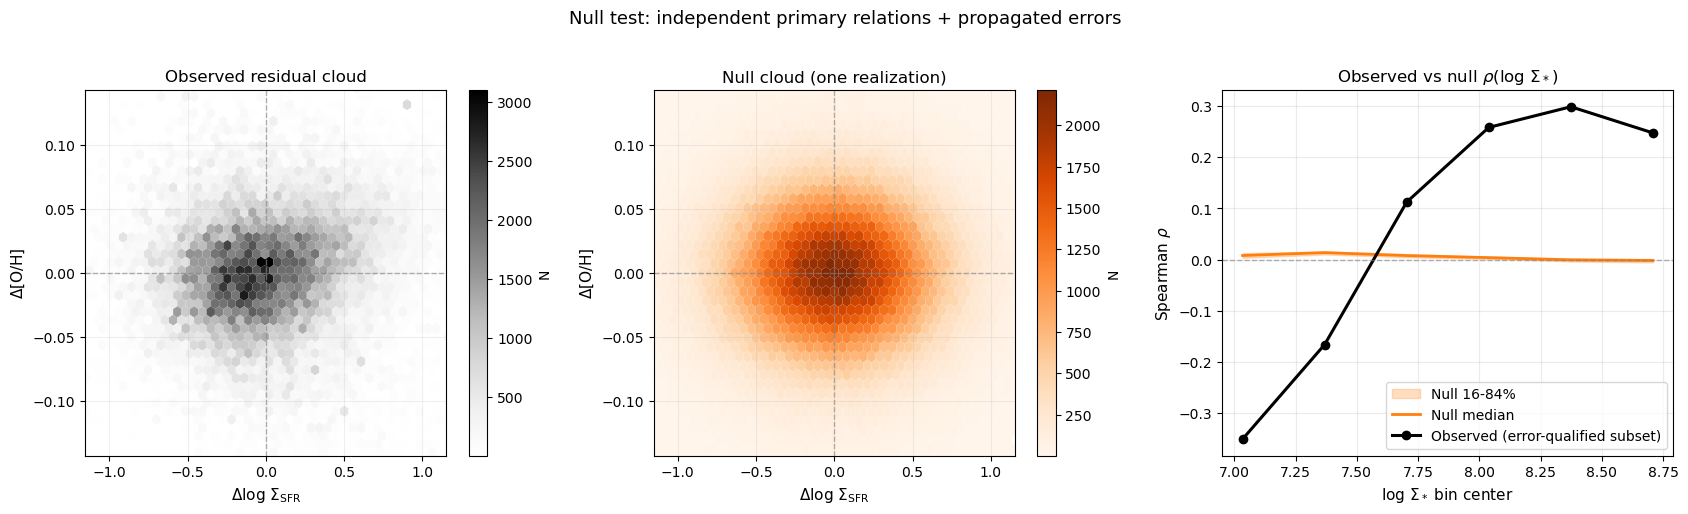

In [7]:
# ------------------------------------------------------------------
# Strengthened null test following Sanchez et al. (2021) Sec. 3.4
# ------------------------------------------------------------------
import numpy as np

from sec34_null_test import (
    compute_rho_curve_from_pipeline,
    load_o3n2_m13_hii_sample_with_errors,
    make_percentile_mass_bin_edges,
    mask_sample,
    plot_sec34_style_null_test,
    print_sec34_summary,
    run_sec34_style_null_test,
)

required = [
    "global_sigM",
    "global_sigSFR",
    "global_oh",
    "global_bin_centers",
    "global_rho_values",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run the global residual-analysis cell first. Missing variables: " + ", ".join(missing))

# ------------------------------------------------------------------
# 1. Silent consistency check against the existing global pipeline
# ------------------------------------------------------------------
global_mass_bin_edges = make_percentile_mass_bin_edges(
    global_sigM,
    n_bins=6,
    lower_percentile=2.5,
    upper_percentile=97.5,
)

global_check = compute_rho_curve_from_pipeline(
    global_sigM,
    global_sigSFR,
    global_oh,
    mass_bin_edges=global_mass_bin_edges,
    bin_width=0.2,
    min_unique=20,
    min_trend_points=3,
)

expected_centers = np.asarray(global_bin_centers, dtype=float)
expected_rho = np.asarray(global_rho_values, dtype=float)
helper_centers = np.asarray(global_check["centers"], dtype=float)
helper_rho = np.asarray(global_check["rho"], dtype=float)
helper_valid = np.isfinite(helper_rho)
helper_centers = helper_centers[helper_valid]
helper_rho = helper_rho[helper_valid]

if expected_centers.size != helper_centers.size:
    raise RuntimeError(
        "Silent validation failed: the helper did not recover the same number of valid global rho bins."
    )

stored_order = np.argsort(expected_centers)
helper_order = np.argsort(helper_centers)
expected_centers = expected_centers[stored_order]
expected_rho = expected_rho[stored_order]
helper_centers = helper_centers[helper_order]
helper_rho = helper_rho[helper_order]

if not np.allclose(expected_centers, helper_centers, atol=1e-10, equal_nan=True):
    raise RuntimeError("Silent validation failed: the helper recovered different mass-bin centers.")

if not np.allclose(expected_rho, helper_rho, atol=1e-12, equal_nan=True):
    raise RuntimeError("Silent validation failed: the helper did not reproduce the expected rho values.")

# ------------------------------------------------------------------
# 2. Build the propagated-error sample used by the null test
# ------------------------------------------------------------------
sec34_full = load_o3n2_m13_hii_sample_with_errors(excluded_galaxies={"NGC4383"})
finite_error_mask = np.isfinite(sec34_full["sigma_log_sfr"]) & np.isfinite(sec34_full["sigma_oh"])
sec34_sample = mask_sample(sec34_full, finite_error_mask)

print("=" * 100)
print(f"Simulation sample with finite propagated uncertainties: {np.sum(finite_error_mask)}")
print(f"Fraction retained after requiring finite propagated uncertainties: {np.sum(finite_error_mask) / global_sigM.size:.3f}")
print("The same 6 global mass bins are used for the observed sample and all null realizations.")
print("=" * 100)

# ------------------------------------------------------------------
# 3. Run the Sec. 3.4-style null test with the global mass bins
# ------------------------------------------------------------------
sec34_result = run_sec34_style_null_test(
    sec34_sample,
    mass_bin_edges=global_mass_bin_edges,
    n_realizations=100,
    random_seed=726,
    include_mass_error_proxy=True,
    mass_error_base=0.01,
)

print_sec34_summary(sec34_result)
plot_sec34_style_null_test(sec34_result)


### Per-Galaxy Sec. 3.4 Panels

This cell runs the same Sec. 3.4-style null-test logic galaxy by galaxy. Each galaxy gets three panels: the observed residual cloud, one null realization, and the galaxy-specific `rho(log Sigma_*)` trend. The black observed curve and the orange null envelope use the same galaxy-specific mass-bin edges, with those edges defined once from the observed galaxy and then reused for all null realizations of that galaxy. In the trend panel, the orange null envelope is masked to the same bins where the observed black curve is defined, so the visual comparison is made only over the bins that survive the observed Spearman-quality cut. The blue dotted curve is the combined observed trend for comparison only, so it keeps the global ensemble binning and does not need to land at the same x positions as the galaxy-specific black and orange curves. `NGC4383` is shown with a dashed black observed line because it is not included in the ensemble trend.


/Users/Igniz/Desktop/ICRAR/extended/sec34_null_test.py:495: RuntimeWarning: All-NaN slice encountered
  "median_rho": np.nanmedian(rho_matrix, axis=0),
/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


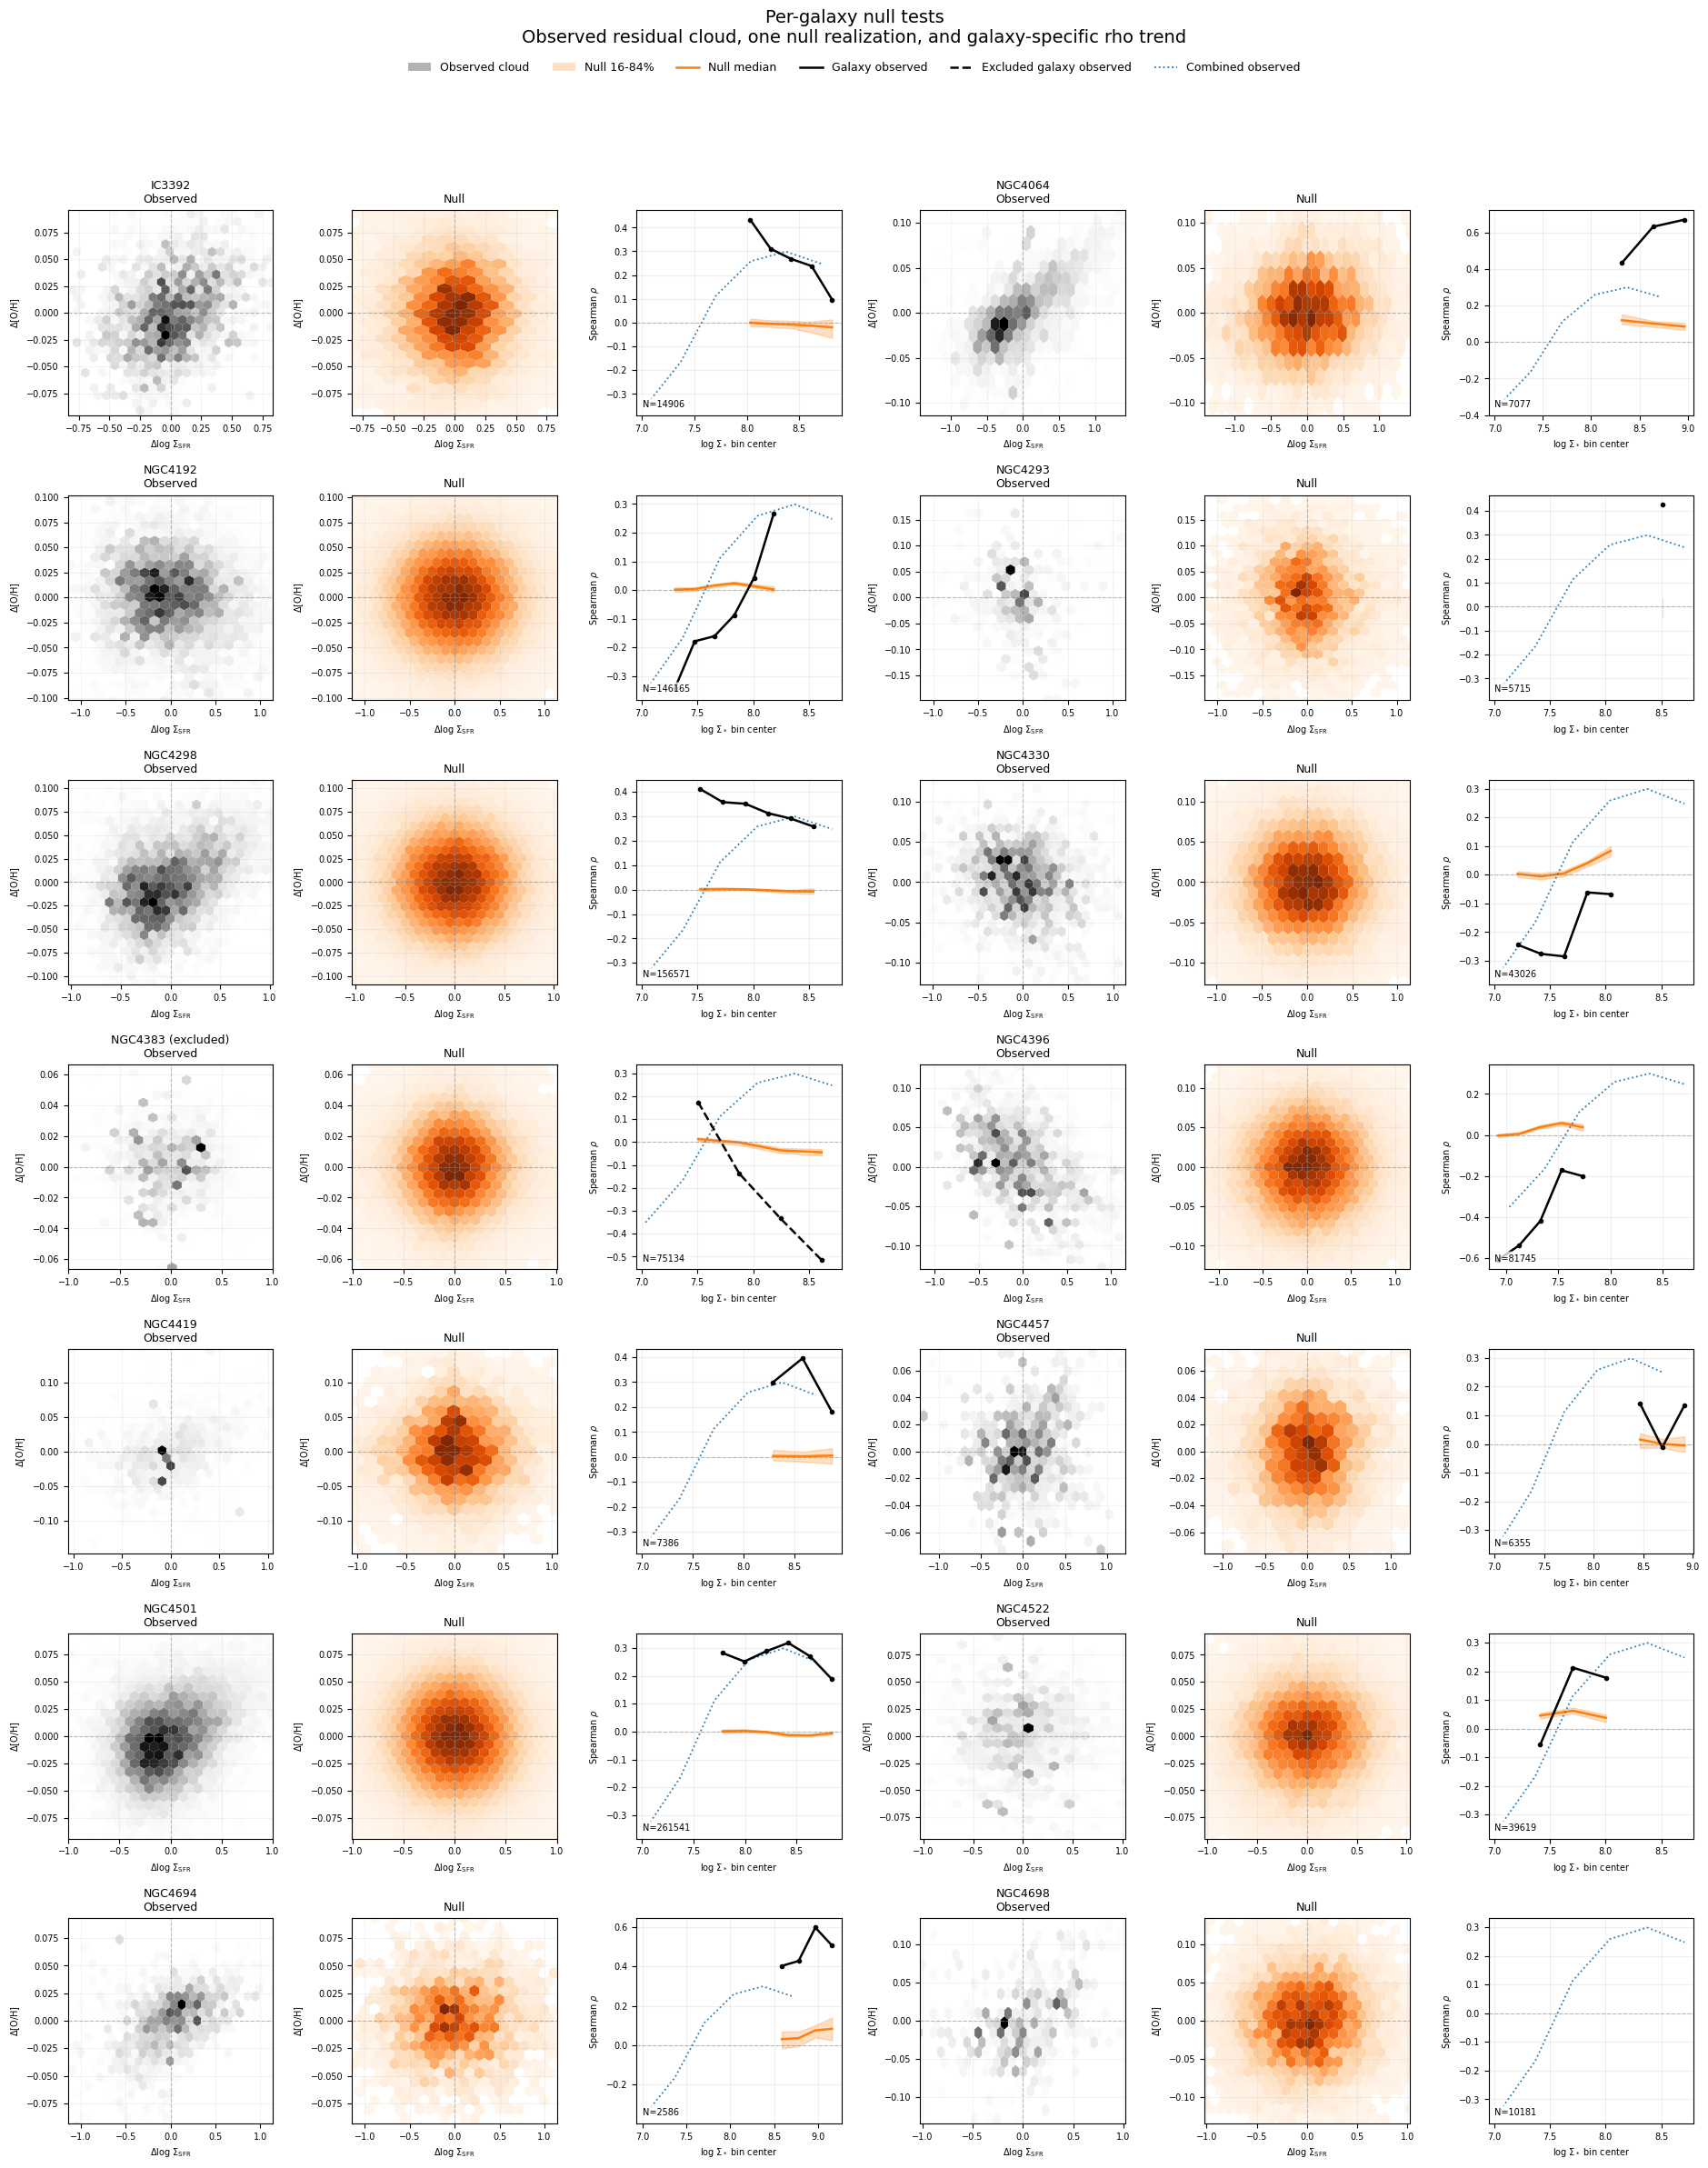

In [8]:
# ------------------------------------------------------------------
# Per-galaxy Sec. 3.4-style null tests in a 7x6 panel grid
# ------------------------------------------------------------------
import numpy as np

from sec34_null_test import (
    list_available_galaxies,
    load_o3n2_m13_hii_sample_with_errors,
    mask_sample,
    plot_sec34_galaxy_grid,
    run_sec34_style_null_test_by_galaxy,
)

required = ["global_sigM", "global_bin_centers", "global_rho_values"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run the global residual-analysis cell first. Missing variables: " + ", ".join(missing))

all_sec34 = load_o3n2_m13_hii_sample_with_errors(excluded_galaxies=())
finite_error_mask_all = np.isfinite(all_sec34["sigma_log_sfr"]) & np.isfinite(all_sec34["sigma_oh"])
all_sec34 = mask_sample(all_sec34, finite_error_mask_all)

galaxy_order = list_available_galaxies()
per_gal_sec34 = run_sec34_style_null_test_by_galaxy(
    all_sec34,
    galaxy_order=galaxy_order,
    n_bins=6,
    n_realizations=100,
    random_seed=726,
    include_mass_error_proxy=True,
    mass_error_base=0.05,
)

combined_curve = {
    "centers": np.asarray(global_bin_centers, dtype=float),
    "rho": np.asarray(global_rho_values, dtype=float),
    "label": "Combined observed",
}

plot_sec34_galaxy_grid(
    per_gal_sec34["galaxy_results"],
    galaxy_order=per_gal_sec34["galaxy_order"],
    combined_curve=combined_curve,
    excluded_galaxies={"NGC4383"},
)


### Simulated Moran Maps for NGC4501 and NGC4192

This cell draws one null realization for each selected galaxy from the Sec. 3.4 simulation and maps the simulated spaxel values back onto the original footprint. The offset maps use 12 local `Sigma_*` bins, and the Moran-like panel follows the same local bivariate statistic and symmetric-log color scaling used in `20260202_Moran_MAUVE14.ipynb`.


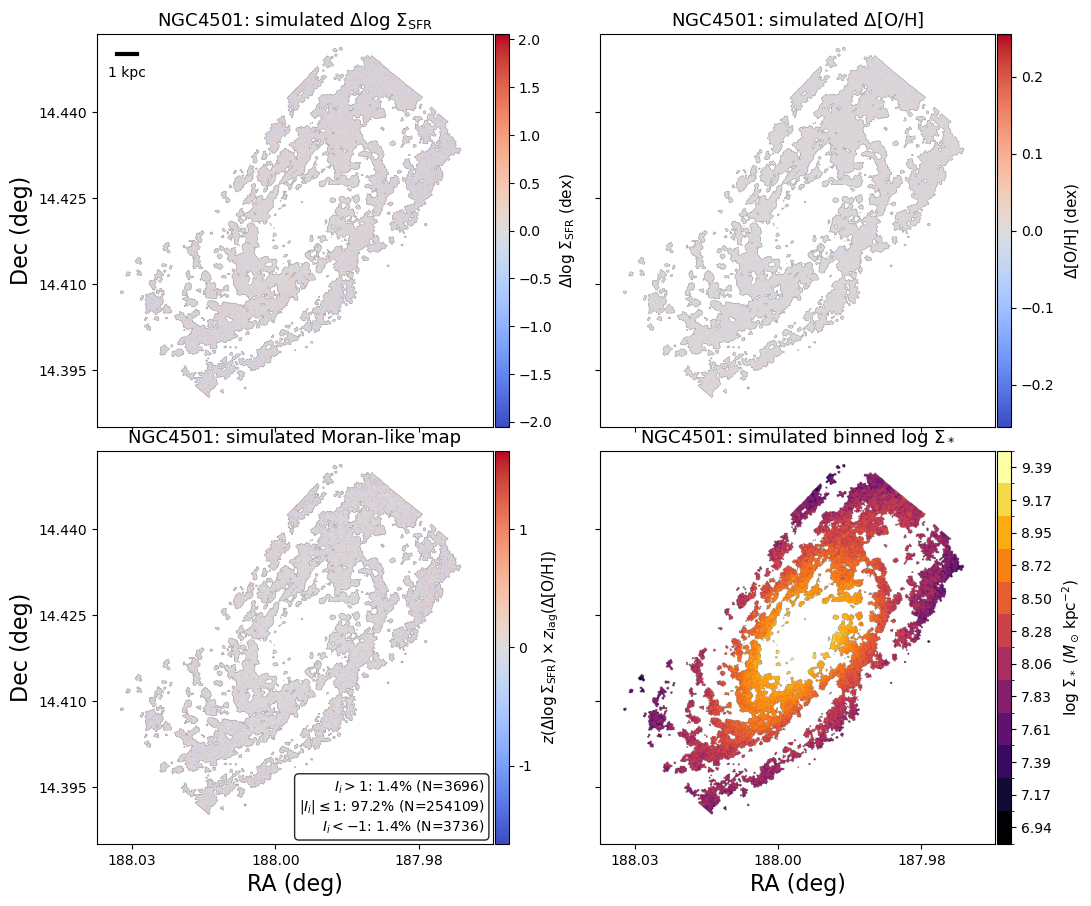

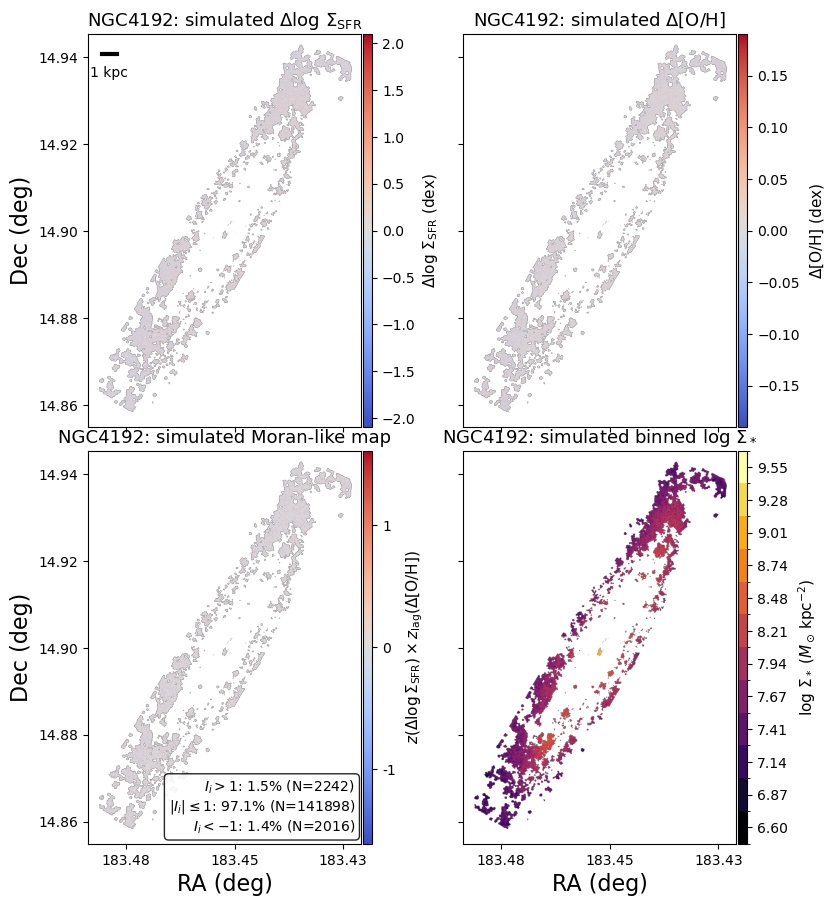

In [9]:
# ------------------------------------------------------------------
# Simulated 2x2 Moran-style maps for selected galaxies
# ------------------------------------------------------------------
from sec34_null_test import build_simulated_moran_maps_for_galaxy, plot_simulated_moran_2x2

simulated_moran_targets = {
    "NGC4501": 4501,
    "NGC4192": 4192,
}

simulated_moran_results = {}
for galaxy, seed in simulated_moran_targets.items():
    simulated_moran_results[galaxy] = build_simulated_moran_maps_for_galaxy(
        galaxy,
        random_seed=seed,
        null_n_bins=6,
        offset_n_bins=12,
        include_mass_error_proxy=True,
        mass_error_base=0.05,
        neighbourhood="queen",
        threshold=1.0,
    )
    plot_simulated_moran_2x2(simulated_moran_results[galaxy])
